In [10]:
import pandas as pd
from functools import reduce

data_path = r"J:\Research\Research\database\Dataset.xlsx"

# Read sheets
df1 = pd.read_excel(data_path, sheet_name='Sheet1')  # X1
df2 = pd.read_excel(data_path, sheet_name='Sheet2')  # X2
df3 = pd.read_excel(data_path, sheet_name='Sheet3')  # X3
df4 = pd.read_excel(data_path, sheet_name='Sheet4')  # X4
df5 = pd.read_excel(data_path, sheet_name='Sheet5')  # X5
df6 = pd.read_excel(data_path, sheet_name='Sheet6')  # X6
df7 = pd.read_excel(data_path, sheet_name='Sheet7')  # Y1
df8 = pd.read_excel(data_path, sheet_name='Sheet8')  # Y1
df9 = pd.read_excel(data_path, sheet_name='Sheet9')  # Y1
# Merge all dataframes
dfs = [df1, df2, df3, df4, df5, df6, df7, df8, df9]

merged_df = reduce(
    lambda left, right: pd.merge(
        left, right,
        on=['ParentLocation', 'Location', 'Period'],
        how='inner'
    ),
    dfs
)

# Save as new file (same folder)
output_path = r"J:\Research\Research\database\Final_Dataset.xlsx"
merged_df.to_excel(output_path, index=False)

print("✅ Final dataset created successfully!")

✅ Final dataset created successfully!


In [12]:
import pandas as pd


data_path = r"J:\Research\Research\database\Diabetes_Dataset.xlsx"
df = pd.read_excel(data_path, sheet_name='Data1')
df

,Region,Country,Year,X1,X2,X3,X4,X5,X6,Y1,...,Y14,Y15,Y16,Y17,Y18,Y19,Y20,Y21,Y22,Y23
0,Eastern Mediterranean,Afghanistan,1990,10.56,13.91,14.33,10.86,10.22,13.44,22.24,...,8.738469,2.215200,27.952003,17.264035,25.863636,27.952003,57.091304,16.71,0.249800,2.02
1,Eastern Mediterranean,Afghanistan,1991,10.76,14.15,14.58,11.06,10.41,13.68,22.28,...,7.972000,5.231641,27.952003,17.376660,25.863636,27.952003,57.091304,16.71,0.401523,2.02
2,Eastern Mediterranean,Afghanistan,1992,10.97,14.41,14.84,11.28,10.61,13.92,22.33,...,7.958000,5.231641,27.952003,17.488203,25.863636,27.952003,57.091304,16.71,0.401523,2.02
3,Eastern Mediterranean,Afghanistan,1993,11.19,14.68,15.12,11.51,10.83,14.18,22.38,...,7.908000,5.231641,27.952003,17.600467,25.863636,27.952003,57.091304,16.71,0.401523,2.02
4,Eastern Mediterranean,Afghanistan,1994,11.42,14.96,15.41,11.75,11.05,14.44,22.43,...,7.883000,5.231641,27.952003,17.715260,25.863636,27.952003,57.091304,16.71,0.401523,2.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6562,Americas,Venezuela (Bolivarian Republic of),2022,10.68,13.89,12.65,9.55,11.86,15.22,56.84,...,6.788000,7.012799,7.319201,35.408554,31.000000,7.319201,45.400000,114.77,1.610083,2.01
6563,Western Pacific,Viet Nam,2022,10.92,13.93,14.21,11.13,10.40,13.22,30.25,...,7.373000,7.012799,22.705652,36.183764,30.000000,22.705652,46.700000,55.11,1.610083,1.66
6564,Eastern Mediterranean,Yemen,2022,18.32,23.15,23.78,18.89,17.62,22.34,40.34,...,8.617000,7.012799,20.847051,37.009767,28.200000,20.847051,52.700000,51.14,1.610083,1.70
6565,Africa,Zambia,2022,12.64,15.70,17.16,13.94,11.23,14.08,14.12,...,9.540000,7.012799,21.485653,37.869206,24.800000,21.485653,49.000000,60.90,1.610083,1.77


In [15]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# -----------------------------
# Load data
# -----------------------------
data_path = r"J:\Research\Research\database\Diabetes_Dataset.xlsx"
df = pd.read_excel(data_path, sheet_name='Data1')

# -----------------------------
# Function to calculate VIF
# -----------------------------
def calculate_vif(dataframe):
    X = dataframe.copy()
    X = X.dropna()

    # Add intercept
    X["Intercept"] = 1

    vif_df = pd.DataFrame()
    vif_df["Variable"] = X.columns
    vif_df["VIF"] = [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]

    # Remove intercept
    vif_df = vif_df[vif_df["Variable"] != "Intercept"]

    return vif_df.sort_values(by="VIF", ascending=False)


# -----------------------------
# Define full variable list
# -----------------------------
all_Y = [f"Y{i}" for i in range(1, 24)]

# -----------------------------
# Scenario 1: Keep BOTH (Y1), drop male (Y3) & female (Y2)
# -----------------------------
scenario1_vars = [y for y in all_Y if y not in ["Y2", "Y3"]]
vif_s1 = calculate_vif(df[scenario1_vars])

# -----------------------------
# Scenario 2: Keep MALE (Y3), drop both (Y1) & female (Y2)
# -----------------------------
scenario2_vars = [y for y in all_Y if y not in ["Y1", "Y2"]]
vif_s2 = calculate_vif(df[scenario2_vars])

# -----------------------------
# Scenario 3: Keep FEMALE (Y2), drop both (Y1) & male (Y3)
# -----------------------------
scenario3_vars = [y for y in all_Y if y not in ["Y1", "Y3"]]
vif_s3 = calculate_vif(df[scenario3_vars])

# -----------------------------
# Save to Excel (3 sheets)
# -----------------------------
output_path = r"J:\Research\Research\database\VIF_results.xlsx"

with pd.ExcelWriter(output_path) as writer:
    vif_s1.to_excel(writer, sheet_name="Both_Model", index=False)
    vif_s2.to_excel(writer, sheet_name="Male_Model", index=False)
    vif_s3.to_excel(writer, sheet_name="Female_Model", index=False)

print("VIF results saved successfully")

C:\Users\Abu Bokkor Shiddik\AppData\Roaming\jupyterlab-desktop\envs\env_1\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
C:\Users\Abu Bokkor Shiddik\AppData\Roaming\jupyterlab-desktop\envs\env_1\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
C:\Users\Abu Bokkor Shiddik\AppData\Roaming\jupyterlab-desktop\envs\env_1\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


VIF results saved successfully


In [17]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# -----------------------------
# Load data
# -----------------------------
data_path = r"J:\Research\Research\database\Diabetes_Dataset.xlsx"
df = pd.read_excel(data_path, sheet_name='Data1')

# -----------------------------
# VIF function
# -----------------------------
def calculate_vif(dataframe):
    X = dataframe.copy()
    X = X.dropna()

    # Add intercept
    X["Intercept"] = 1

    vif_df = pd.DataFrame()
    vif_df["Variable"] = X.columns
    vif_df["VIF"] = [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]

    # Remove intercept
    vif_df = vif_df[vif_df["Variable"] != "Intercept"]

    return vif_df.sort_values(by="VIF", ascending=False)


# -----------------------------
# Define variables (exclude Y16, Y19 globally)
# -----------------------------
all_Y = [f"Y{i}" for i in range(1, 24)]
exclude_vars = ["Y16", "Y19", "Y4"]

filtered_Y = [y for y in all_Y if y not in exclude_vars]

# -----------------------------
# Scenario 1: BOTH (keep Y1, drop Y2, Y3)
# -----------------------------
scenario1_vars = [y for y in filtered_Y if y not in ["Y2", "Y3"]]
vif_s1 = calculate_vif(df[scenario1_vars])

# -----------------------------
# Scenario 2: MALE (keep Y3, drop Y1, Y2)
# -----------------------------
scenario2_vars = [y for y in filtered_Y if y not in ["Y1", "Y2"]]
vif_s2 = calculate_vif(df[scenario2_vars])

# -----------------------------
# Scenario 3: FEMALE (keep Y2, drop Y1, Y3)
# -----------------------------
scenario3_vars = [y for y in filtered_Y if y not in ["Y1", "Y3"]]
vif_s3 = calculate_vif(df[scenario3_vars])

# -----------------------------
# Save to Excel
# -----------------------------
output_path = r"J:\Research\Research\database\VIF_results_updated.xlsx"

with pd.ExcelWriter(output_path) as writer:
    vif_s1.to_excel(writer, sheet_name="Both_Model", index=False)
    vif_s2.to_excel(writer, sheet_name="Male_Model", index=False)
    vif_s3.to_excel(writer, sheet_name="Female_Model", index=False)

print("Updated VIF results saved successfully")

Updated VIF results saved successfully


In [19]:
import pandas as pd

# -----------------------------
# Load data
# -----------------------------
data_path = r"J:\Research\Research\database\Diabetes_Dataset.xlsx"
df = pd.read_excel(data_path, sheet_name='Data1')

# -----------------------------
# Group by Region
# -----------------------------
region_table = (
    df.groupby("Region")["Country"]
    .agg(lambda x: ", ".join(sorted(set(x))))
    .reset_index()
)

# -----------------------------
# Count number of countries per region
# -----------------------------
region_table["No_of_Countries"] = region_table["Country"].apply(
    lambda x: len(x.split(", "))
)

# -----------------------------
# Rename columns (clean format)
# -----------------------------
region_table.columns = ["Region", "Countries", "No_of_Countries"]

# -----------------------------
# Save to Excel
# -----------------------------
output_path = r"J:\Research\Research\database\Region_Summary_Table.xlsx"

region_table.to_excel(output_path, index=False)

print("Region summary table saved successfully")

Region summary table saved successfully


In [3]:
"""
Missing Data Analysis — Diabetes Panel Dataset
================================================
Checks missing data patterns by variable, country, year, and region.
Outputs: console summary + 4 saved figures + missingness classification.

Usage:
    python missing_data_analysis.py
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
import os
warnings.filterwarnings("ignore")

# ── Optional: missingno ───────────────────────────────────────────────────────
try:
    import missingno as msno
    HAS_MSNO = True
except ImportError:
    HAS_MSNO = False
    print("[INFO] missingno not installed — skipping msno plots.")

# ─────────────────────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────────────────────
DATA_PATH   = r"J:\Research\Research\database\Diabetes_Dataset.xlsx"
OUTPUT_DIR  = r"J:\Research\Research\database\results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

SHEET_NAME  = "missing"
ID_COLS     = ["Region", "Country", "Year"]
YEAR_COL    = "Year"
COUNTRY_COL = "Country"
REGION_COL  = "Region"

MISSING_THRESHOLD_HIGH = 30
MISSING_THRESHOLD_LOW  = 5

PALETTE = {
    "header":  "#534AB7",
    "low":     "#1D9E75",
    "mid":     "#EF9F27",
    "high":    "#E24B4A",
    "bar":     "#7F77DD",
    "grid":    "#E8E8E8",
}

# ─────────────────────────────────────────────────────────────────────────────
# LOAD DATA
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 65)
print("  DIABETES PANEL DATASET — MISSING DATA AUDIT")
print("=" * 65)

df = pd.read_excel(DATA_PATH, sheet_name=SHEET_NAME)

print(f"\nDataset shape : {df.shape[0]:,} rows × {df.shape[1]} columns")

analytic_cols = [c for c in df.columns if c not in ID_COLS]
numeric_df    = df[analytic_cols].apply(pd.to_numeric, errors="coerce")

total_cells   = numeric_df.size
missing_cells = numeric_df.isnull().sum().sum()

print(f"\nTotal missing %: {missing_cells/total_cells*100:.2f}")

# ─────────────────────────────────────────────────────────────────────────────
# 2. PER-VARIABLE SUMMARY
# ─────────────────────────────────────────────────────────────────────────────
miss_var = (numeric_df.isnull().sum() / len(numeric_df) * 100).sort_values(ascending=False)

miss_var_df = pd.DataFrame({
    "Variable": miss_var.index,
    "Missing_N": numeric_df.isnull().sum().values,
    "Missing_pct": miss_var.values.round(2),
    "Status": pd.cut(
        miss_var.values,
        bins=[-1, MISSING_THRESHOLD_LOW, MISSING_THRESHOLD_HIGH, 100],
        labels=["Clean (<5%)", "Moderate (5–30%)", "High (>30%)"]
    )
})

# ─────────────────────────────────────────────────────────────────────────────
# 3. PER-YEAR
# ─────────────────────────────────────────────────────────────────────────────
miss_year = df.groupby(YEAR_COL)[analytic_cols].apply(
    lambda g: g.apply(pd.to_numeric, errors="coerce").isnull().mean().mean() * 100
).reset_index()

# ─────────────────────────────────────────────────────────────────────────────
# 4. PER-COUNTRY
# ─────────────────────────────────────────────────────────────────────────────
miss_country = df.groupby(COUNTRY_COL)[analytic_cols].apply(
    lambda g: g.apply(pd.to_numeric, errors="coerce").isnull().mean().mean() * 100
).reset_index()

miss_country.columns = [COUNTRY_COL, "Missing_pct"]
miss_country = miss_country.sort_values("Missing_pct", ascending=False)

# ─────────────────────────────────────────────────────────────────────────────
# 5. PER-REGION
# ─────────────────────────────────────────────────────────────────────────────
miss_region = df.groupby(REGION_COL)[analytic_cols].apply(
    lambda g: g.apply(pd.to_numeric, errors="coerce").isnull().mean().mean() * 100
).reset_index()

miss_region.columns = [REGION_COL, "Missing_pct"]

# ─────────────────────────────────────────────────────────────────────────────
# STYLE
# ─────────────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": PALETTE["grid"]
})

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 1
# ─────────────────────────────────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(8, 6))

colors = [
    PALETTE["high"] if v > MISSING_THRESHOLD_HIGH else
    PALETTE["mid"] if v > MISSING_THRESHOLD_LOW else
    PALETTE["low"]
    for v in miss_var_df["Missing_pct"]
]

ax1.barh(miss_var_df["Variable"], miss_var_df["Missing_pct"], color=colors)
ax1.invert_yaxis()

ax1.set_title("Missing data by variable", loc="left")

fig1_path = os.path.join(OUTPUT_DIR, "fig1_variable.png")
fig1.savefig(fig1_path, dpi=300, bbox_inches="tight")
plt.close()

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 2
# ─────────────────────────────────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(8, 4))

ax2.plot(miss_year[YEAR_COL], miss_year.iloc[:,1],
         color=PALETTE["header"], marker="o")

ax2.set_title("Missing data over time", loc="left")

fig2_path = os.path.join(OUTPUT_DIR, "fig2_year.png")
fig2.savefig(fig2_path, dpi=300, bbox_inches="tight")
plt.close()

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 3
# ─────────────────────────────────────────────────────────────────────────────
pivot_region = df.groupby(REGION_COL)[analytic_cols].apply(
    lambda g: g.isnull().mean() * 100
)

fig3, ax3 = plt.subplots(figsize=(8, 5))

im = ax3.imshow(pivot_region.values, cmap="YlOrBr", aspect="auto")

ax3.set_title("Region vs variable missingness", loc="left")

fig3.colorbar(im)

fig3_path = os.path.join(OUTPUT_DIR, "fig3_region.png")
fig3.savefig(fig3_path, dpi=300, bbox_inches="tight")
plt.close()

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 4
# ─────────────────────────────────────────────────────────────────────────────
if HAS_MSNO:
    fig4, ax4 = plt.subplots(figsize=(8, 6))
    msno.matrix(numeric_df.sample(min(500, len(numeric_df))), ax=ax4)
    ax4.set_title("Missing structure matrix", loc="left")

    fig4_path = os.path.join(OUTPUT_DIR, "fig4_matrix.png")
    fig4.savefig(fig4_path, dpi=300, bbox_inches="tight")
    plt.close()

else:
    top40 = miss_country.head(40)[COUNTRY_COL]

    pivot_country = df[df[COUNTRY_COL].isin(top40)].groupby(COUNTRY_COL)[analytic_cols].apply(
        lambda g: g.isnull().mean() * 100
    )

    fig4, ax4 = plt.subplots(figsize=(8, 6))

    im = ax4.imshow(pivot_country.values, cmap="YlOrBr", aspect="auto")

    ax4.set_title("Country missingness (top 40)", loc="left")

    fig4.colorbar(im)

    fig4_path = os.path.join(OUTPUT_DIR, "fig4_country.png")
    fig4.savefig(fig4_path, dpi=300, bbox_inches="tight")
    plt.close()

# ─────────────────────────────────────────────────────────────────────────────
# SAVE TABLES (CSV)
# ─────────────────────────────────────────────────────────────────────────────
miss_var_df.to_csv(os.path.join(OUTPUT_DIR, "variable_summary.csv"), index=False)
miss_country.to_csv(os.path.join(OUTPUT_DIR, "country_summary.csv"), index=False)
miss_region.to_csv(os.path.join(OUTPUT_DIR, "region_summary.csv"), index=False)

# ─────────────────────────────────────────────────────────────────────────────
# FINAL
# ─────────────────────────────────────────────────────────────────────────────
print("\nSaved all outputs to:", OUTPUT_DIR)
print("Figures: fig1–fig4 PNG")
print("Tables: CSV summaries")

overall = missing_cells / total_cells * 100
print("Overall missing:", round(overall, 2), "%")

  DIABETES PANEL DATASET — MISSING DATA AUDIT

Dataset shape : 6,567 rows × 32 columns

Total missing %: 0.29

Saved all outputs to: J:\Research\Research\database\results
Figures: fig1–fig4 PNG
Tables: CSV summaries
Overall missing: 0.29 %


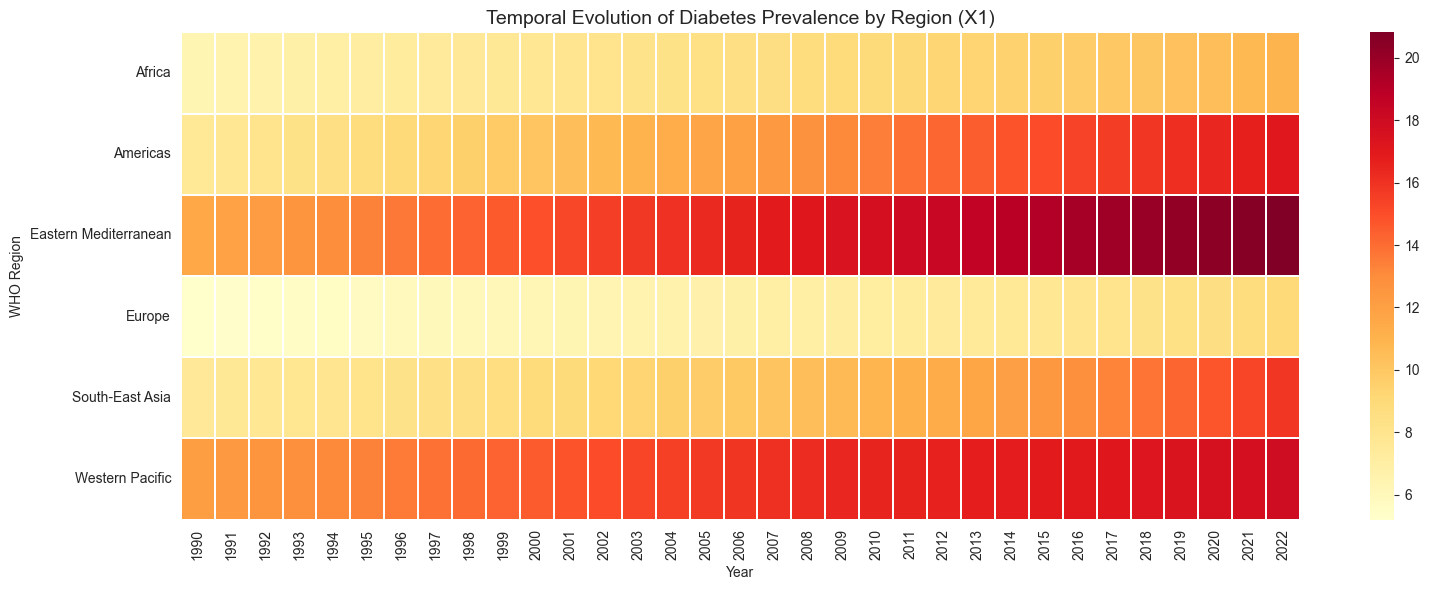

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Load data
# -----------------------------
data_path = r"J:\Research\Research\database\Diabetes_Dataset.xlsx"
df = pd.read_excel(data_path, sheet_name='Data1')

# -----------------------------
# Select variables
# -----------------------------
df = df[['Region', 'Year', 'X1']]

# -----------------------------
# Aggregate by Region-Year
# -----------------------------
df_region_time = df.groupby(['Region','Year']).mean().reset_index()

# -----------------------------
# Pivot to matrix form
# -----------------------------
heatmap_data = df_region_time.pivot(index='Region', columns='Year', values='X1')

# -----------------------------
# Plot heatmap
# -----------------------------
plt.figure(figsize=(16,6))
sns.heatmap(heatmap_data, cmap='YlOrRd', linewidths=0.2)

plt.title("Temporal Evolution of Diabetes Prevalence by Region (X1)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("WHO Region")

plt.tight_layout()
plt.show()

In [6]:
import pandas as pd
import numpy as np

# -----------------------------
# Load data
# -----------------------------
data_path = r"J:\Research\Research\database\Diabetes_Dataset.xlsx"
df = pd.read_excel(data_path, sheet_name="Data1")

cols = ["X1","X2","X3","X4","X5","X6"]

# -----------------------------
# 1. Overall summary
# -----------------------------
overall_summary = pd.DataFrame()

for c in cols:
    overall_summary.loc[c, "Mean"] = df[c].mean()
    overall_summary.loc[c, "SD"] = df[c].std()
    overall_summary.loc[c, "Min"] = df[c].min()
    overall_summary.loc[c, "Q1"] = df[c].quantile(0.25)
    overall_summary.loc[c, "Median"] = df[c].median()
    overall_summary.loc[c, "Q3"] = df[c].quantile(0.75)
    overall_summary.loc[c, "Max"] = df[c].max()

# -----------------------------
# 2. Regional summary
# -----------------------------
regional_summary = df.groupby("Region")[cols].agg(["mean","std","min","max","median"])

# -----------------------------
# 3. Year wise summary
# -----------------------------
yearly_summary = df.groupby("Year")[cols].mean().reset_index()

# -----------------------------
# 4. Country level summary
# -----------------------------
country_mean = df.groupby("Country")[cols].mean()
country_global_mean = country_mean.mean(axis=1)

top5_global = country_global_mean.sort_values(ascending=False).head(5).to_frame("Top5_Global")
bottom5_global = country_global_mean.sort_values(ascending=True).head(5).to_frame("Bottom5_Global")

# -----------------------------
# 5. Year wise top/bottom 5 countries
# -----------------------------
year_top_bottom = []

for year in sorted(df["Year"].unique()):
    temp = df[df["Year"] == year]
    country_mean_year = temp.groupby("Country")[cols].mean().mean(axis=1)

    top5 = country_mean_year.sort_values(ascending=False).head(5)
    bottom5 = country_mean_year.sort_values(ascending=True).head(5)

    tmp_df = pd.DataFrame({
        "Year": year,
        "Top5_Country": top5.index,
        "Top5_Value": top5.values
    })

    tmp_df2 = pd.DataFrame({
        "Year": year,
        "Bottom5_Country": bottom5.index,
        "Bottom5_Value": bottom5.values
    })

    year_top_bottom.append(tmp_df)
    year_top_bottom.append(tmp_df2)

year_top_bottom_df = pd.concat(year_top_bottom, ignore_index=True)

# -----------------------------
# 6. Age gap analysis
# -----------------------------
df["Age_gap_both"] = df["X2"] - df["X1"]
df["Age_gap_female"] = df["X4"] - df["X3"]
df["Age_gap_male"] = df["X6"] - df["X5"]

age_gap_summary = df[["Age_gap_both","Age_gap_female","Age_gap_male"]].describe()

age_gap_region = df.groupby("Region")[["Age_gap_both","Age_gap_female","Age_gap_male"]].mean().reset_index()

# -----------------------------
# 7. Gender gap analysis
# -----------------------------
df["Gender_gap_18+"] = df["X5"] - df["X4"]
df["Gender_gap_30+"] = df["X6"] - df["X3"]

gender_gap_summary = df[["Gender_gap_18+","Gender_gap_30+"]].describe()
gender_gap_region = df.groupby("Region")[["Gender_gap_18+","Gender_gap_30+"]].mean().reset_index()

# -----------------------------
# 8. Save all to Excel
# -----------------------------
output_path = r"J:\Research\Research\database\results\Diabetes_EDA_Output.xlsx"

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    overall_summary.to_excel(writer, sheet_name="Overall_Summary")
    regional_summary.to_excel(writer, sheet_name="Regional_Summary")
    yearly_summary.to_excel(writer, sheet_name="Yearly_Summary")

    top5_global.to_excel(writer, sheet_name="Top5_Global")
    bottom5_global.to_excel(writer, sheet_name="Bottom5_Global")

    year_top_bottom_df.to_excel(writer, sheet_name="Yearly_TopBottom", index=False)

    age_gap_summary.to_excel(writer, sheet_name="AgeGap_Summary")
    age_gap_region.to_excel(writer, sheet_name="AgeGap_Region")

    gender_gap_summary.to_excel(writer, sheet_name="GenderGap_Summary")
    gender_gap_region.to_excel(writer, sheet_name="GenderGap_Region")

print("Excel file saved successfully:", output_path)

Excel file saved successfully: J:\Research\Research\database\results\Diabetes_EDA_Output.xlsx


In [9]:
import pandas as pd
import numpy as np
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.utils.dataframe import dataframe_to_rows

# -----------------------------
# Load data
# -----------------------------
data_path = r"J:\Research\Research\database\Diabetes_Dataset.xlsx"
df = pd.read_excel(data_path, sheet_name="Data1")

cols = ["X1","X2","X3","X4","X5","X6"]

# -----------------------------
# tables
# -----------------------------
global_summary = pd.DataFrame()

for c in cols:
    global_summary.loc[c, "Mean ± SD"] = f"{df[c].mean():.2f} ± {df[c].std():.2f}"
    global_summary.loc[c, "Median"] = df[c].median()
    global_summary.loc[c, "Q1–Q3"] = f"{df[c].quantile(0.25):.2f}–{df[c].quantile(0.75):.2f}"
    global_summary.loc[c, "Min–Max"] = f"{df[c].min():.2f}–{df[c].max():.2f}"

regional_summary = df.groupby("Region")[cols].mean().round(2)
yearly_summary = df.groupby("Year")[cols].mean().reset_index()

country_mean = df.groupby("Country")[cols].mean().mean(axis=1)
top5 = country_mean.sort_values(ascending=False).head(5)
bottom5 = country_mean.sort_values(ascending=True).head(5)

ranking = pd.DataFrame({
    "Top 5 Countries": top5.index,
    "Top Value": top5.values,
    "Bottom 5 Countries": bottom5.index,
    "Bottom Value": bottom5.values
})

df["Age_gap_18_30"] = df["X2"] - df["X1"]
df["Age_gap_female"] = df["X4"] - df["X3"]
df["Age_gap_male"] = df["X6"] - df["X5"]

df["Gender_gap_18+"] = df["X5"] - df["X4"]
df["Gender_gap_30+"] = df["X6"] - df["X3"]

gap_summary = df[[
    "Age_gap_18_30",
    "Age_gap_female",
    "Age_gap_male",
    "Gender_gap_18+",
    "Gender_gap_30+"
]].describe().T

gap_region = df.groupby("Region")[[
    "Age_gap_18_30",
    "Age_gap_female",
    "Age_gap_male",
    "Gender_gap_18+",
    "Gender_gap_30+"
]].mean().round(2)

# -----------------------------
# styling setup (Lancet style)
# -----------------------------
header_fill = PatternFill(start_color="1F4E79", end_color="1F4E79", fill_type="solid")  # dark navy
region_fill = PatternFill(start_color="D9E1F2", end_color="D9E1F2", fill_type="solid")   # light blue
bold_font = Font(bold=True, color="FFFFFF")
region_bold = Font(bold=True)

center_align = Alignment(horizontal="center", vertical="center")

# -----------------------------
# workbook
# -----------------------------
wb = Workbook()

def style_sheet(ws):
    for row in ws.iter_rows():
        for cell in row:
            cell.alignment = center_align

# -----------------------------
# SHEET 1: GLOBAL + REGIONAL
# -----------------------------
ws1 = wb.active
ws1.title = "Table 1 Epidemiology"

ws1.append(["X Variable", "Mean ± SD", "Median", "Q1–Q3", "Min–Max"])

for cell in ws1[1]:
    cell.fill = header_fill
    cell.font = bold_font
    cell.alignment = center_align

for idx, row in global_summary.iterrows():
    ws1.append([idx] + list(row.values))

for r in ws1.iter_rows(min_row=2):
    for c in r:
        c.alignment = center_align

ws1.append([])
ws1.append(["Regional Summary"])
ws1.append(list(regional_summary.columns))

for cell in ws1[ws1.max_row]:
    cell.fill = header_fill
    cell.font = bold_font

for idx, row in regional_summary.iterrows():
    ws1.append([idx] + list(row.values))

# bold region rows
for r in ws1.iter_rows(min_row=ws1.max_row - len(regional_summary), max_row=ws1.max_row):
    r[0].font = region_bold
    for c in r:
        c.fill = region_fill

style_sheet(ws1)

# -----------------------------
# SHEET 2: YEARLY + RANKING
# -----------------------------
ws2 = wb.create_sheet("Table 2 Temporal")

ws2.append(yearly_summary.columns.tolist())
for cell in ws2[1]:
    cell.fill = header_fill
    cell.font = bold_font

for row in dataframe_to_rows(yearly_summary, index=False, header=False):
    ws2.append(row)

ws2.append([])
ws2.append(["Country Ranking"])
ws2.append(list(ranking.columns))

for cell in ws2[ws2.max_row]:
    cell.fill = header_fill
    cell.font = bold_font

for row in dataframe_to_rows(ranking, index=False, header=False):
    ws2.append(row)

style_sheet(ws2)

# -----------------------------
# SHEET 3: GAP ANALYSIS
# -----------------------------
ws3 = wb.create_sheet("Table 3 Inequality")

ws3.append(["Indicator"] + list(gap_summary.columns))

for cell in ws3[1]:
    cell.fill = header_fill
    cell.font = bold_font

for idx, row in gap_summary.iterrows():
    ws3.append([idx] + list(row.values))

ws3.append([])
ws3.append(["Regional Gap Summary"])
ws3.append(list(gap_region.columns))

for cell in ws3[ws3.max_row]:
    cell.fill = header_fill
    cell.font = bold_font

for idx, row in gap_region.iterrows():
    ws3.append([idx] + list(row.values))

# region shading + bold
start_row = ws3.max_row - len(gap_region)
for r in ws3.iter_rows(min_row=start_row, max_row=ws3.max_row):
    r[0].font = region_bold
    for c in r:
        c.fill = region_fill

style_sheet(ws3)

# -----------------------------
# SAVE FILE
# -----------------------------
output_path = r"J:\Research\Research\database\results\Diabetes_Lancet_Style_Table.xlsx"
wb.save(output_path)

print("Saved Lancet styled Excel:", output_path)

Saved Lancet styled Excel: J:\Research\Research\database\results\Diabetes_Lancet_Style_Table.xlsx


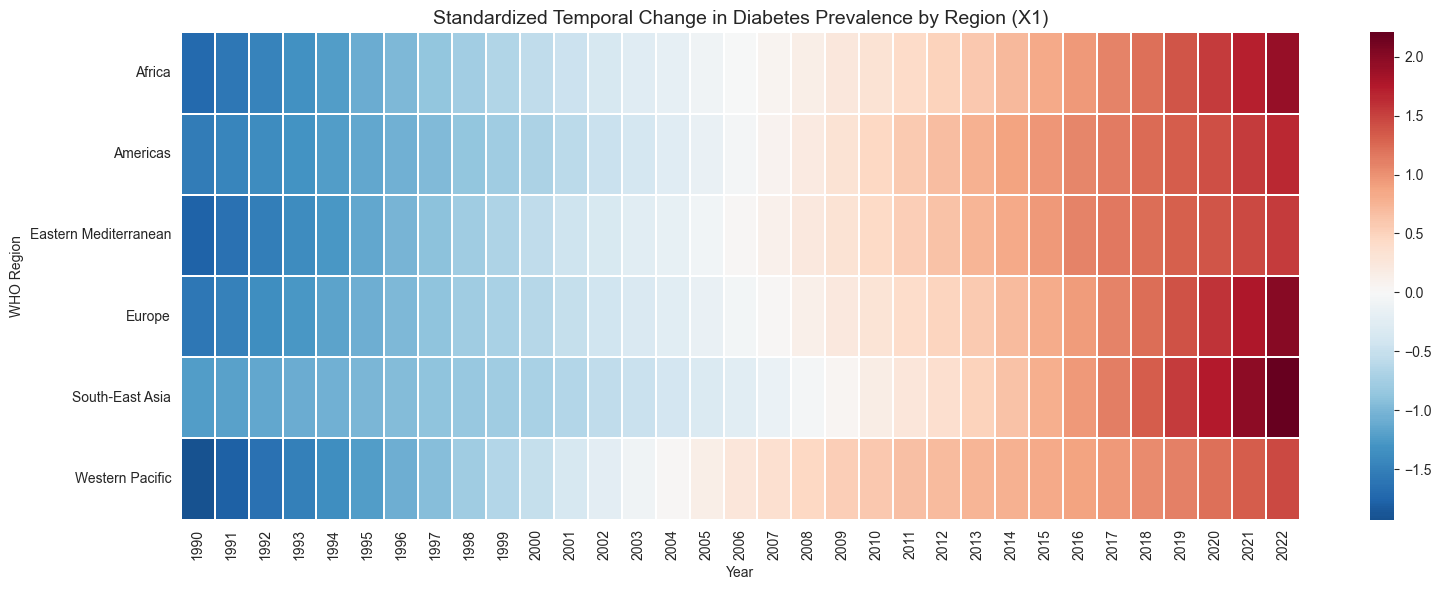

In [27]:
heatmap_data_z = (heatmap_data - heatmap_data.mean(axis=1).values.reshape(-1,1)) / heatmap_data.std(axis=1).values.reshape(-1,1)

plt.figure(figsize=(16,6))
sns.heatmap(heatmap_data_z, cmap='RdBu_r', center=0, linewidths=0.2)

plt.title("Standardized Temporal Change in Diabetes Prevalence by Region (X1)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("WHO Region")

plt.tight_layout()
plt.show()

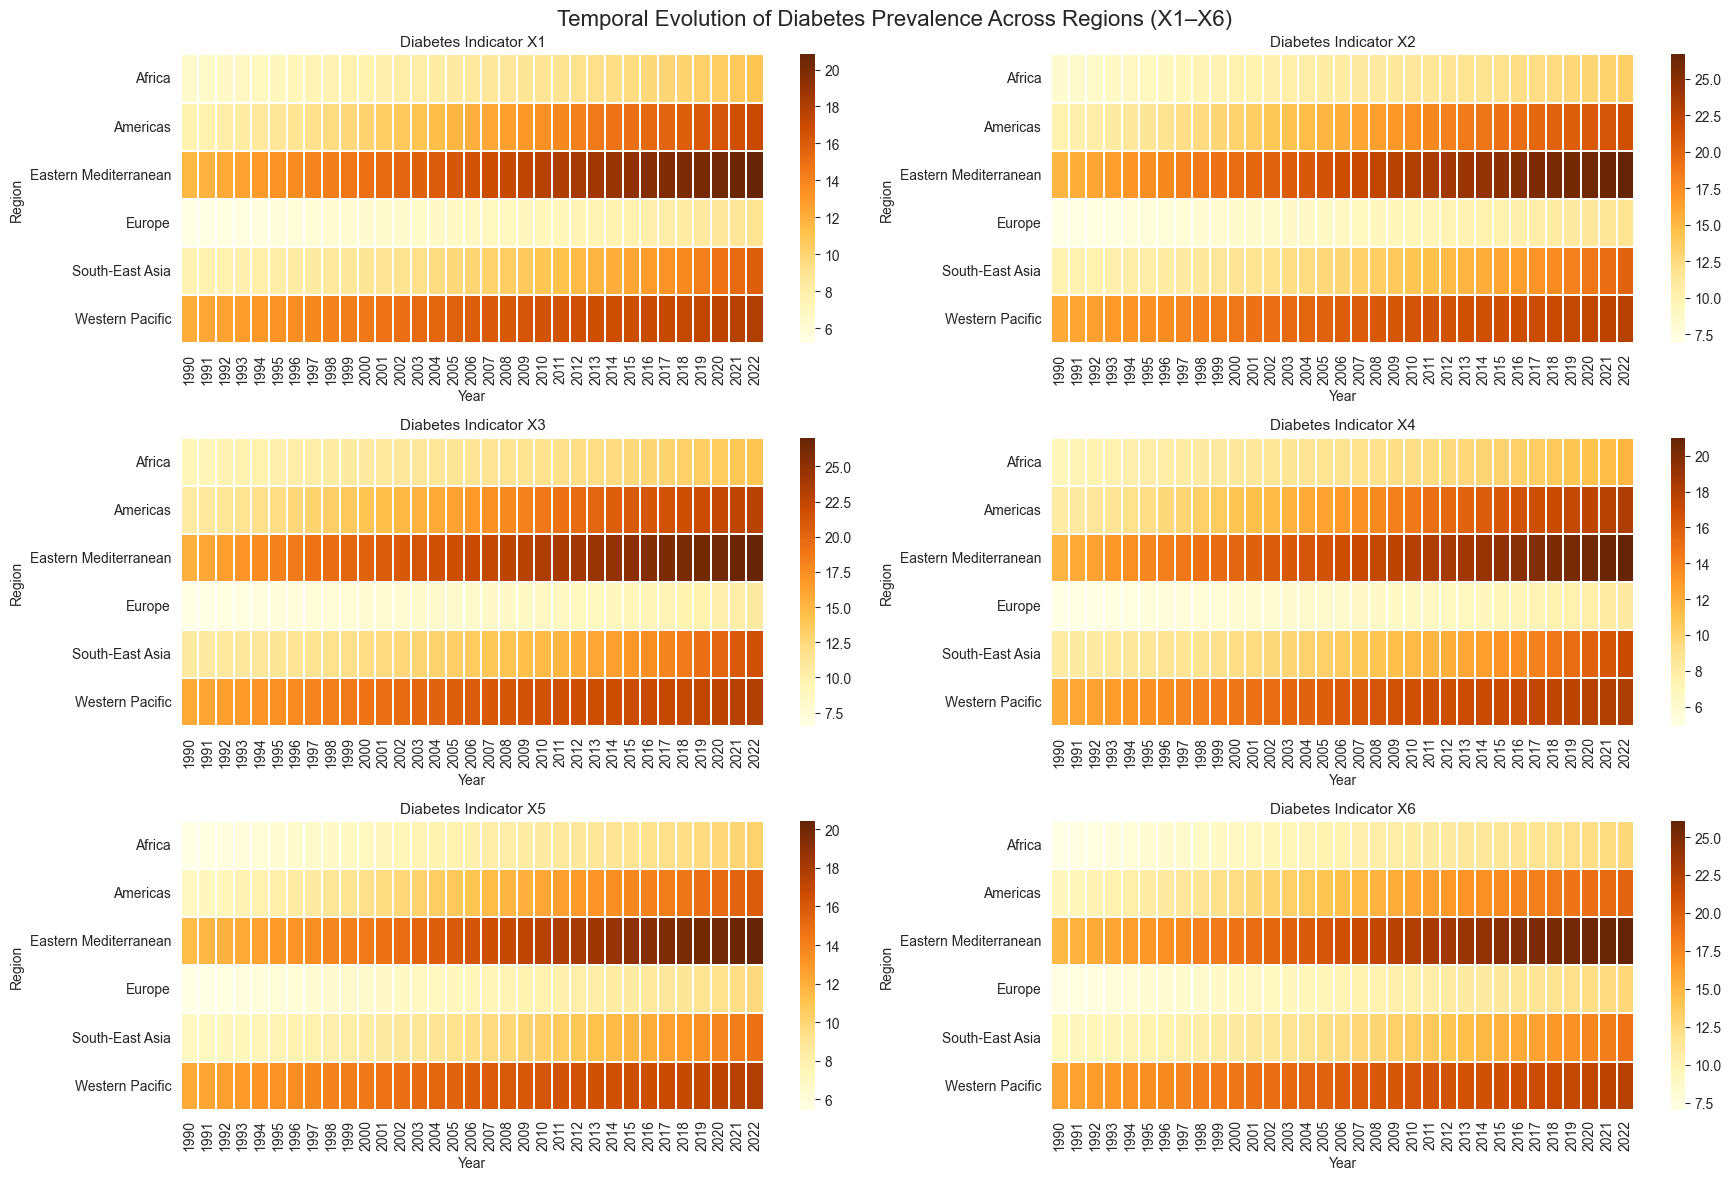

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Load data
# -----------------------------
data_path = r"J:\Research\Research\database\Diabetes_Dataset.xlsx"
df = pd.read_excel(data_path, sheet_name='Data1')

# -----------------------------
# Indicators
# -----------------------------
indicators = ['X1','X2','X3','X4','X5','X6']

# -----------------------------
# Aggregate by Region-Year
# -----------------------------
df_region_time = df.groupby(['Region','Year'])[indicators].mean().reset_index()

# -----------------------------
# Plot setup
# -----------------------------
sns.set_style("white")
fig, axes = plt.subplots(3, 2, figsize=(18, 12))
axes = axes.flatten()

# Business-style color palette (no standard blue/green)
palette = ['#7F1D1D', '#1E3A8A', '#B45309', '#065F46', '#4C1D95', '#9A3412']

# -----------------------------
# Create heatmaps for X1–X6
# -----------------------------
for i, var in enumerate(indicators):

    heatmap_data = df_region_time.pivot(index='Region', columns='Year', values=var)

    sns.heatmap(
        heatmap_data,
        ax=axes[i],
        cmap='YlOrBr',
        cbar=True,
        linewidths=0.2
    )

    axes[i].set_title(f"Diabetes Indicator {var}", fontsize=11)
    axes[i].set_xlabel("Year")
    axes[i].set_ylabel("Region")

plt.suptitle("Temporal Evolution of Diabetes Prevalence Across Regions (X1–X6)", fontsize=16)
plt.tight_layout()
plt.show()

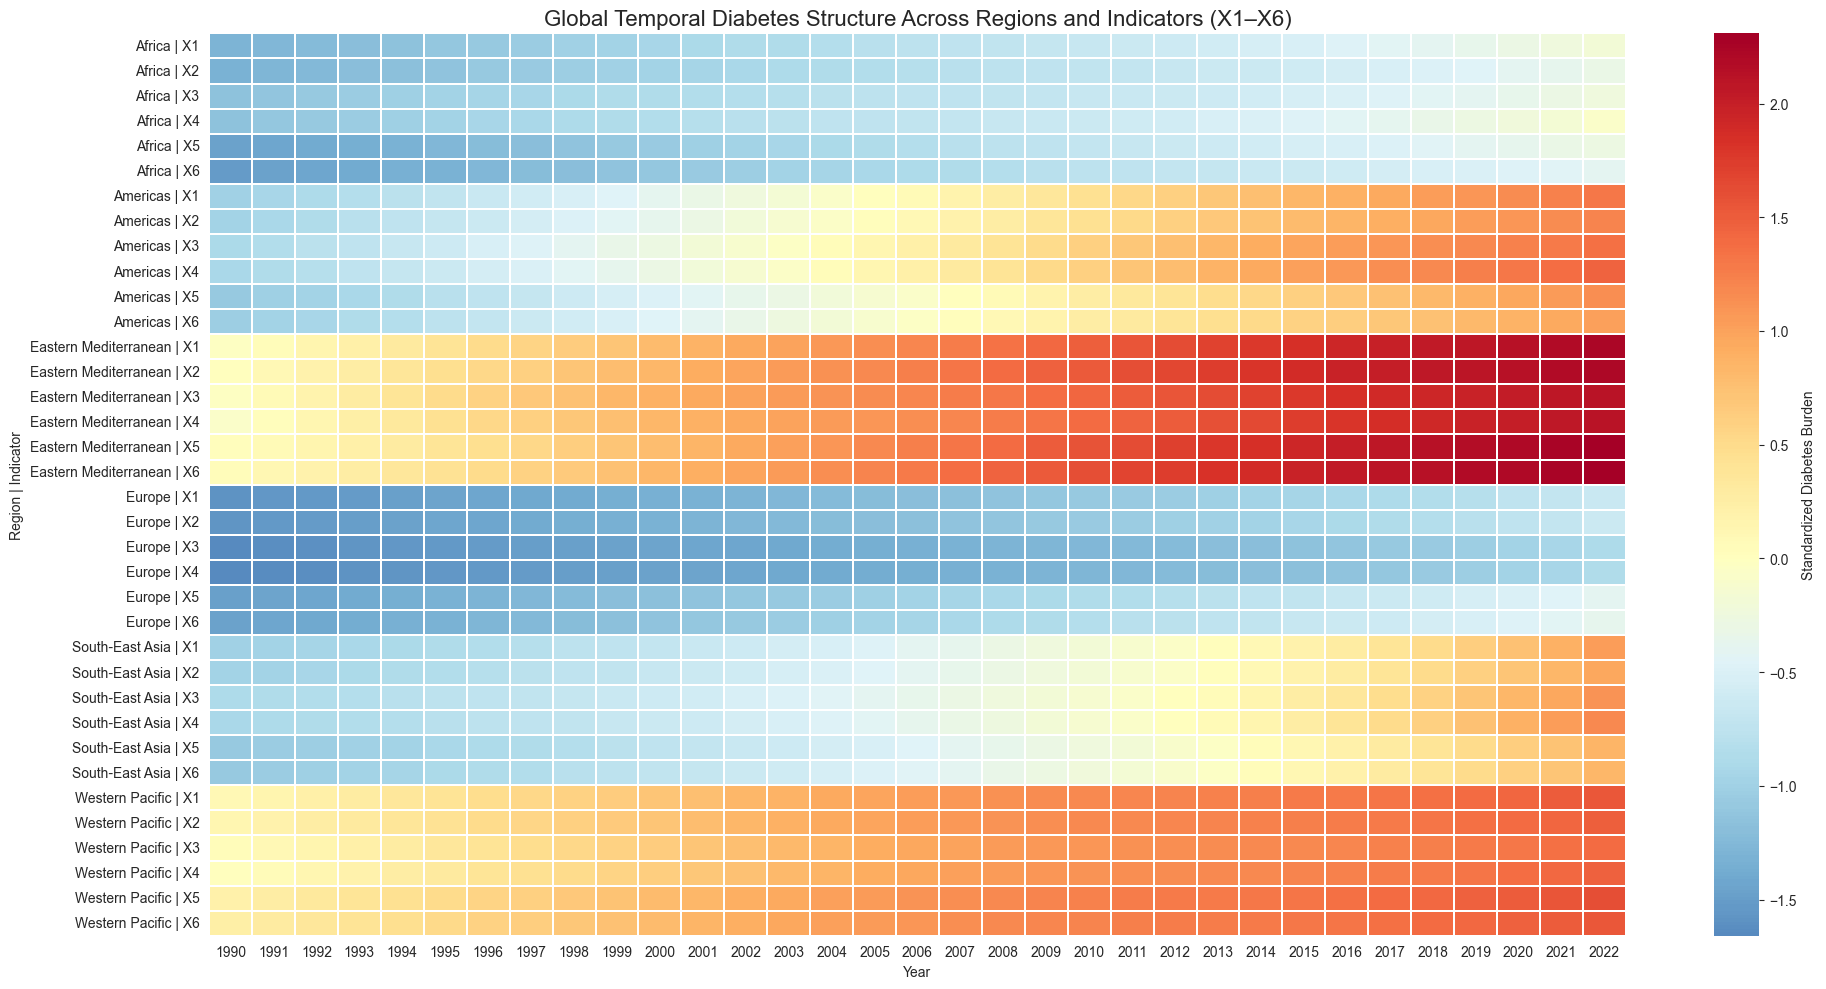

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Load data
# -----------------------------
data_path = r"J:\Research\Research\database\Diabetes_Dataset.xlsx"
df = pd.read_excel(data_path, sheet_name='Data1')

# -----------------------------
# Indicators
# -----------------------------
indicators = ['X1','X2','X3','X4','X5','X6']

# -----------------------------
# Aggregate
# -----------------------------
df_region_time = df.groupby(['Region','Year'])[indicators].mean().reset_index()

# -----------------------------
# Normalize across full dataset (IMPORTANT STEP)
# -----------------------------
df_norm = df_region_time.copy()

for col in indicators:
    df_norm[col] = (df_norm[col] - df_norm[col].mean()) / df_norm[col].std()

# -----------------------------
# Melt into long format
# -----------------------------
df_long = df_norm.melt(
    id_vars=['Region','Year'],
    value_vars=indicators,
    var_name='Indicator',
    value_name='Value'
)

# -----------------------------
# Create pivot (Region × Year × Indicator merged visually)
# -----------------------------
df_long['Region_Indicator'] = df_long['Region'] + " | " + df_long['Indicator']

heatmap_data = df_long.pivot_table(
    index='Region_Indicator',
    columns='Year',
    values='Value',
    aggfunc='mean'
)

# -----------------------------
# Plot SINGLE heatmap
# -----------------------------
plt.figure(figsize=(20, 10))

sns.heatmap(
    heatmap_data,
    cmap='RdYlBu_r',
    center=0,
    linewidths=0.1,
    cbar_kws={'label': 'Standardized Diabetes Burden'}
)

plt.title("Global Temporal Diabetes Structure Across Regions and Indicators (X1–X6)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Region | Indicator")

plt.tight_layout()
plt.show()

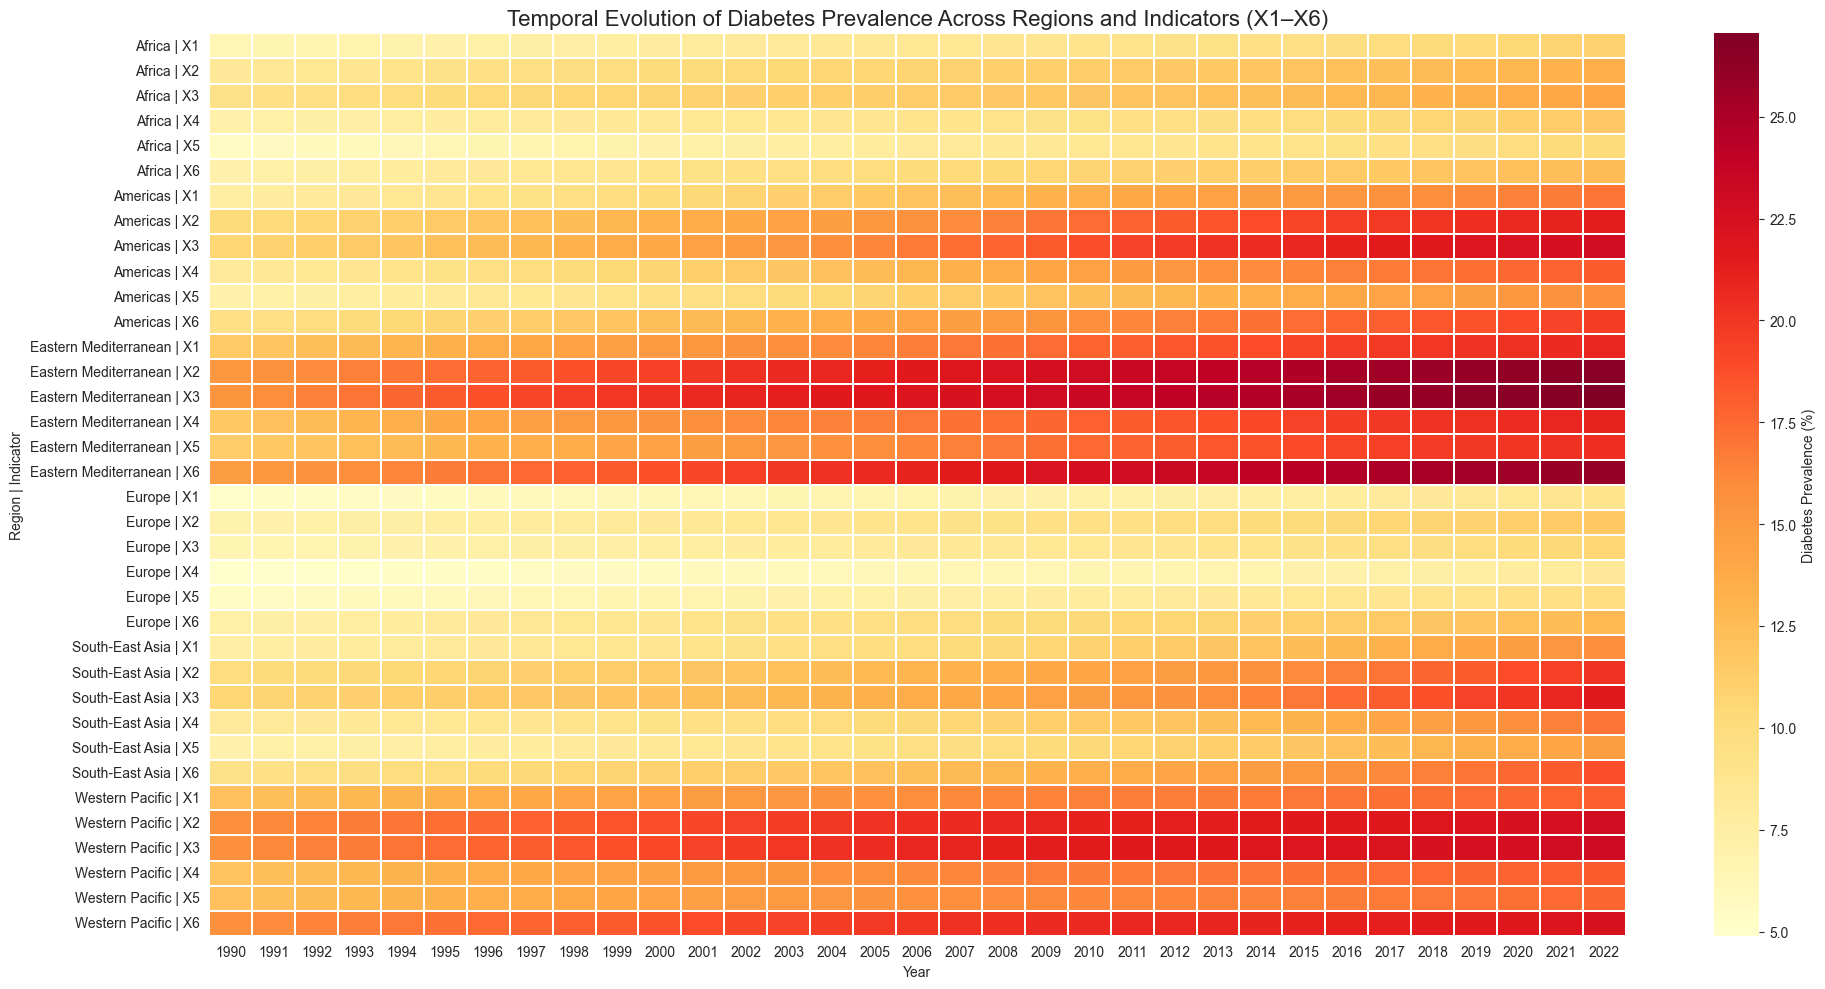

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Load data
# -----------------------------
data_path = r"J:\Research\Research\database\Diabetes_Dataset.xlsx"
df = pd.read_excel(data_path, sheet_name='Data1')

# -----------------------------
# Indicators
# -----------------------------
indicators = ['X1','X2','X3','X4','X5','X6']

# -----------------------------
# Aggregate by Region-Year
# -----------------------------
df_region_time = df.groupby(['Region','Year'])[indicators].mean().reset_index()

# -----------------------------
# Reshape to long format
# -----------------------------
df_long = df_region_time.melt(
    id_vars=['Region','Year'],
    value_vars=indicators,
    var_name='Indicator',
    value_name='Value'
)

# -----------------------------
# Create combined axis label
# -----------------------------
df_long['Region_Indicator'] = df_long['Region'] + " | " + df_long['Indicator']

# -----------------------------
# Pivot for heatmap
# -----------------------------
heatmap_data = df_long.pivot_table(
    index='Region_Indicator',
    columns='Year',
    values='Value',
    aggfunc='mean'
)

# -----------------------------
# Plot SINGLE heatmap (original scale)
# -----------------------------
plt.figure(figsize=(20, 10))

sns.heatmap(
    heatmap_data,
    cmap='YlOrRd',
    linewidths=0.1,
    cbar_kws={'label': 'Diabetes Prevalence (%)'}
)

plt.title("", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Region | Indicator")

plt.tight_layout()
plt.show()

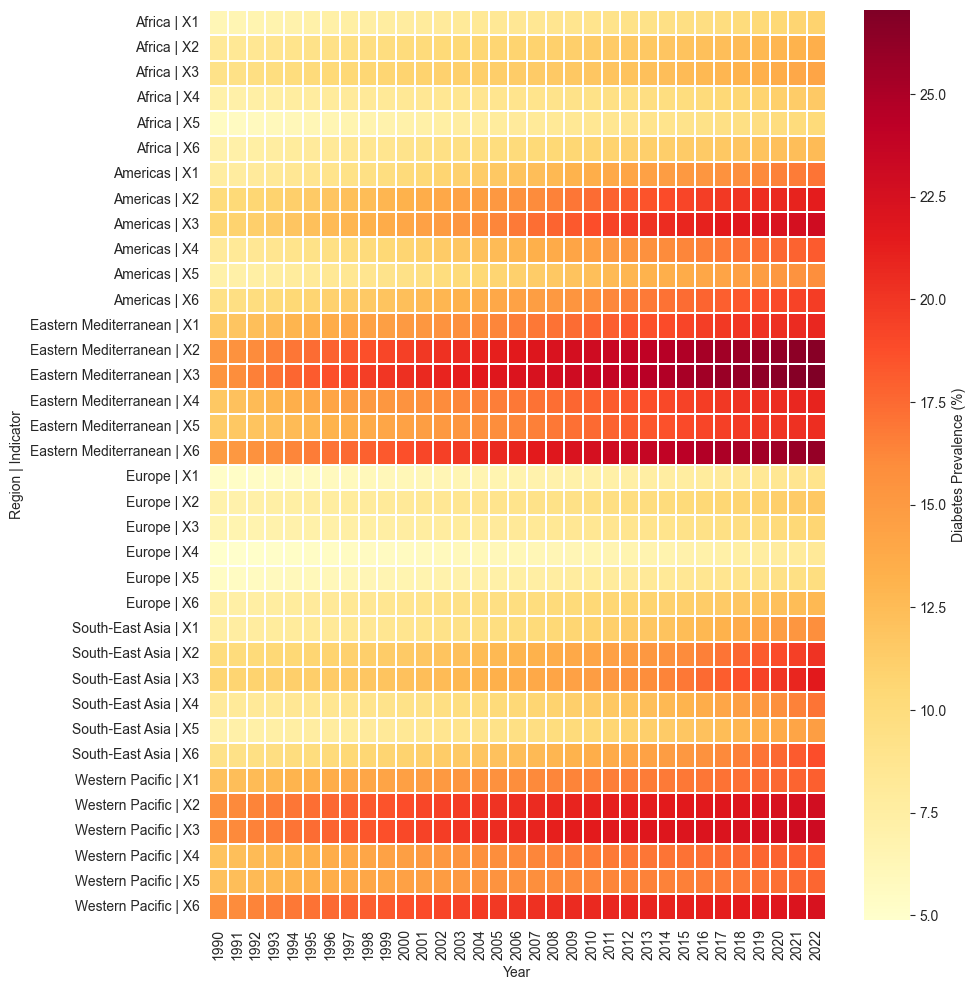

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Load data
# -----------------------------
data_path = r"J:\Research\Research\database\Diabetes_Dataset.xlsx"
df = pd.read_excel(data_path, sheet_name='Data1')

# -----------------------------
# Indicators
# -----------------------------
indicators = ['X1','X2','X3','X4','X5','X6']

# -----------------------------
# Aggregate by Region-Year
# -----------------------------
df_region_time = df.groupby(['Region','Year'])[indicators].mean().reset_index()

# -----------------------------
# Reshape to long format
# -----------------------------
df_long = df_region_time.melt(
    id_vars=['Region','Year'],
    value_vars=indicators,
    var_name='Indicator',
    value_name='Value'
)

# -----------------------------
# Create combined axis label
# -----------------------------
df_long['Region_Indicator'] = df_long['Region'] + " | " + df_long['Indicator']

# -----------------------------
# Pivot for heatmap
# -----------------------------
heatmap_data = df_long.pivot_table(
    index='Region_Indicator',
    columns='Year',
    values='Value',
    aggfunc='mean'
)

# -----------------------------
# Plot SINGLE heatmap
# -----------------------------
plt.figure(figsize=(10, 10))

sns.heatmap(
    heatmap_data,
    cmap='YlOrRd',
    linewidths=0.1,
    cbar_kws={'label': 'Diabetes Prevalence (%)'}
)

plt.title("", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Region | Indicator")

plt.tight_layout()

# -----------------------------
# Save high-resolution figure
# -----------------------------
save_path = r"J:\Research\Research\database\diabetes_temporal_heatmap.png"

plt.savefig(save_path, dpi=600, bbox_inches='tight')

plt.show()

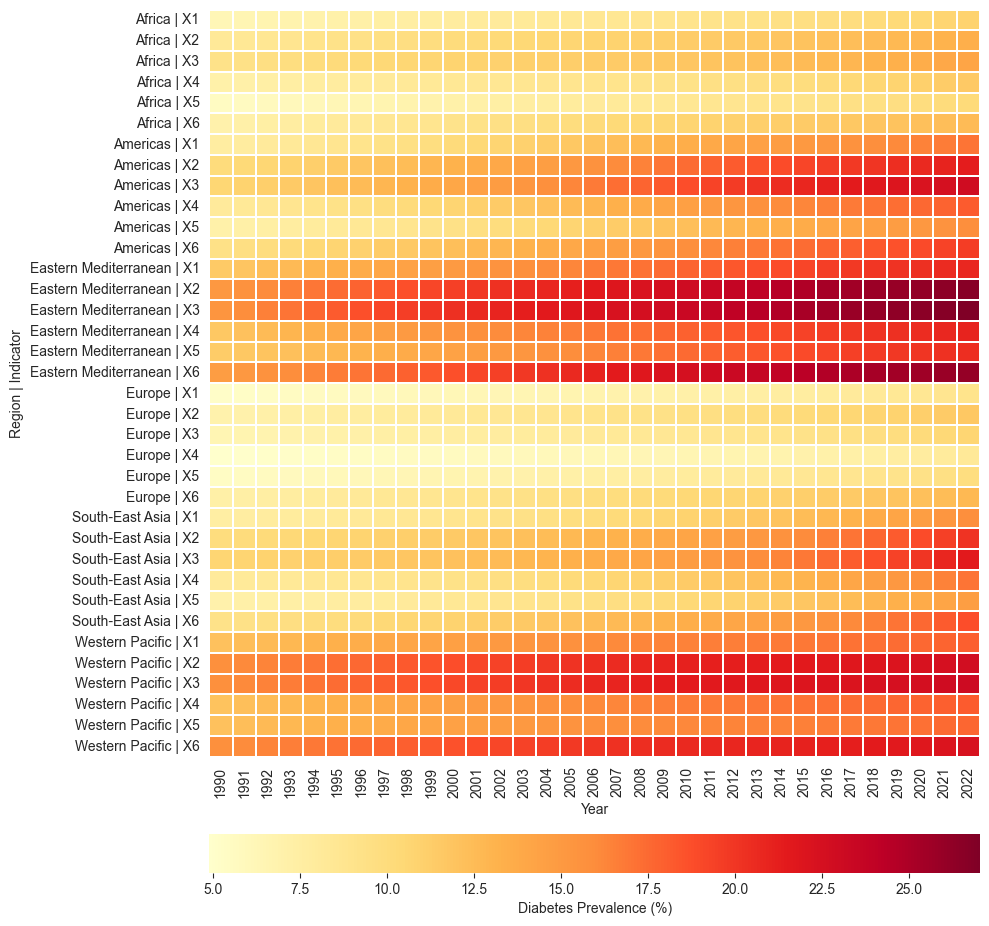

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Load data
# -----------------------------
data_path = r"J:\Research\Research\database\Diabetes_Dataset.xlsx"
df = pd.read_excel(data_path, sheet_name='Data1')

# -----------------------------
# Indicators
# -----------------------------
indicators = ['X1','X2','X3','X4','X5','X6']

# -----------------------------
# Aggregate by Region-Year
# -----------------------------
df_region_time = df.groupby(['Region','Year'])[indicators].mean().reset_index()

# -----------------------------
# Reshape to long format
# -----------------------------
df_long = df_region_time.melt(
    id_vars=['Region','Year'],
    value_vars=indicators,
    var_name='Indicator',
    value_name='Value'
)

# -----------------------------
# Create combined axis label
# -----------------------------
df_long['Region_Indicator'] = df_long['Region'] + " | " + df_long['Indicator']

# -----------------------------
# Pivot for heatmap
# -----------------------------
heatmap_data = df_long.pivot_table(
    index='Region_Indicator',
    columns='Year',
    values='Value',
    aggfunc='mean'
)

# -----------------------------
# Plot SINGLE heatmap with bottom legend
# -----------------------------
plt.figure(figsize=(10, 10))

ax = sns.heatmap(
    heatmap_data,
    cmap='YlOrRd',
    linewidths=0.1,
    cbar_kws={
        'label': 'Diabetes Prevalence (%)',
        'orientation': 'horizontal',   # makes legend bottom
        'pad': 0.08                   # space below plot
    }
)

plt.title("", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Region | Indicator")

plt.tight_layout()

# -----------------------------
# Save high-resolution figure
# -----------------------------
save_path = r"J:\Research\Research\database\11diabetes_temporal_heatmap.png"

plt.savefig(save_path, dpi=600, bbox_inches='tight')

plt.show()

Dataset loaded: (6567, 32)
X shape: (6567, 20)
y shape: (6567,)
Target mean: 10.83, std: 6.13
Column name check passed ✓
Columns: ['Treatment Coverage Both', 'Treatment Coverage Female', 'Treatment Coverage Male', 'Overweight BMI 25plus', 'Underweight BMI 18minus', 'Non-HDL Cholesterol', 'HDL Cholesterol', 'Physical Inactivity', 'Alcohol Consumption', 'Kilocalories per Day', 'GDP per Capita', 'Literacy Rate', 'Unemployment', 'School Enrollment', 'Urban Population', 'Undernourishment', 'Access to Electricity', 'Health Expenditure', 'Hospital Beds', 'Medical Doctors']

Running 5-fold cross-validation...
  Training XGBoost...
    R2=0.898 | RMSE=1.956 | MAE=1.149
  Training Random Forest...
    R2=0.596 | RMSE=3.894 | MAE=2.839
  Training LightGBM...
    R2=0.882 | RMSE=2.100 | MAE=1.269
  Training Elastic Net...
    R2=0.046 | RMSE=5.984 | MAE=4.642

CV Results:
                  R2  R2_std   RMSE  RMSE_std    MAE  MAE_std
XGBoost        0.898   0.008  1.956    -0.045  1.149   -0.038
Ran

ValueError: 'yerr' must not contain negative values

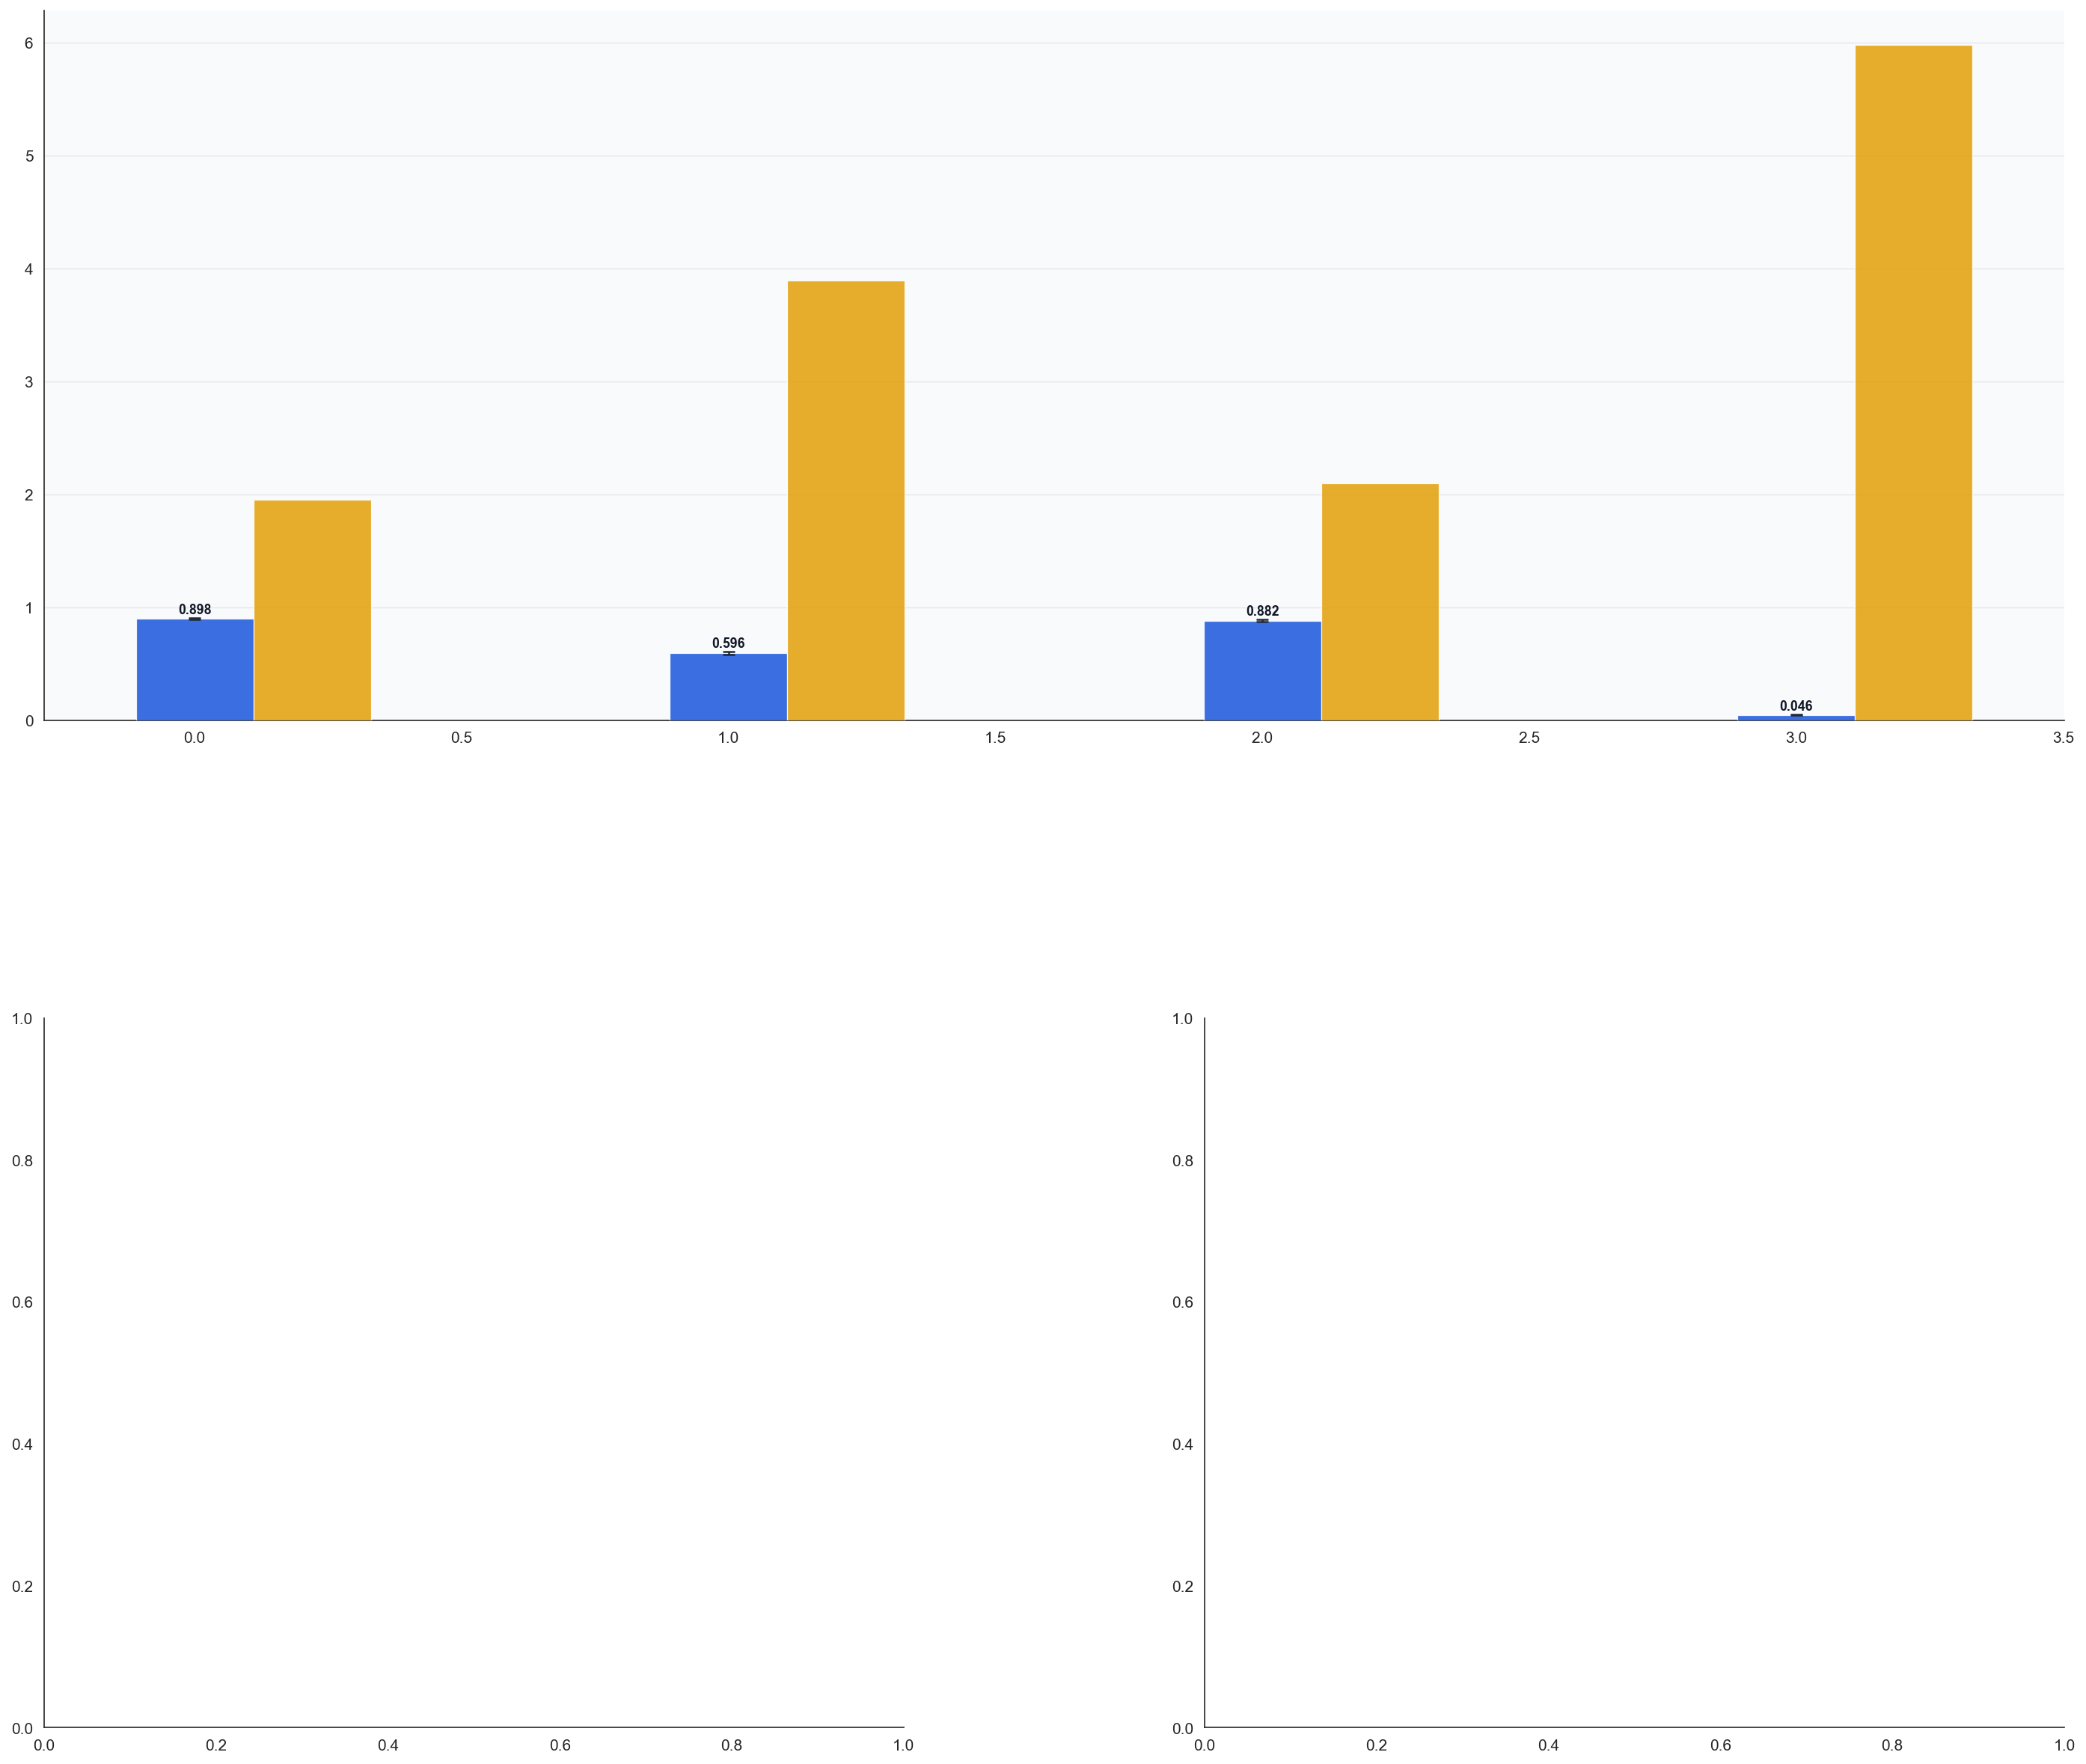

In [44]:
# ════════════════════════════════════════════════════════════════
# FIGURE 2 — FIXED COMPLETE CODE
# ════════════════════════════════════════════════════════════════

# ── 1. IMPORTS ──────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import shap
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import KFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from statsmodels.nonparametric.smoothers_lowess import lowess

# ── 2. LOAD DATA ─────────────────────────────────────────────────
data_path = r"J:\Research\Research\database\Diabetes_Dataset.xlsx"
df = pd.read_excel(data_path, sheet_name='Data1')
print(f"Dataset loaded: {df.shape}")

# ── 3. DEFINE VARIABLES ──────────────────────────────────────────
target = 'X1'  # Diabetes prevalence 18+, Both sexes

# Skip Y4 (Obesity), Y16 (Poverty), Y19 (Agriculture)
predictors = [
    'Y1',  # Treatment coverage both sexes
    'Y2',  # Treatment coverage female
    'Y3',  # Treatment coverage male
    'Y5',  # Overweight
    'Y6',  # Underweight
    'Y7',  # Non-HDL cholesterol
    'Y8',  # HDL cholesterol
    'Y9',  # Physical inactivity
    'Y10', # Alcohol consumption
    'Y11', # Kilocalories
    'Y12', # GDP per capita
    'Y13', # Literacy rate
    'Y14', # Unemployment
    'Y15', # School enrollment
    'Y17', # Urban population
    'Y18', # Undernourishment
    'Y20', # Access to electricity
    'Y21', # Health expenditure
    'Y22', # Hospital beds
    'Y23', # Medical doctors
]

# ── CLEAN labels — NO special characters for XGBoost ────────────
predictor_labels = {
    'Y1':  'Treatment Coverage Both',
    'Y2':  'Treatment Coverage Female',
    'Y3':  'Treatment Coverage Male',
    'Y5':  'Overweight BMI 25plus',
    'Y6':  'Underweight BMI 18minus',
    'Y7':  'Non-HDL Cholesterol',
    'Y8':  'HDL Cholesterol',
    'Y9':  'Physical Inactivity',
    'Y10': 'Alcohol Consumption',
    'Y11': 'Kilocalories per Day',
    'Y12': 'GDP per Capita',
    'Y13': 'Literacy Rate',
    'Y14': 'Unemployment',
    'Y15': 'School Enrollment',
    'Y17': 'Urban Population',
    'Y18': 'Undernourishment',
    'Y20': 'Access to Electricity',
    'Y21': 'Health Expenditure',
    'Y22': 'Hospital Beds',
    'Y23': 'Medical Doctors',
}

# Display labels for plots (can have special characters)
display_labels = {
    'Y1':  'Treatment Coverage (Both)',
    'Y2':  'Treatment Coverage (Female)',
    'Y3':  'Treatment Coverage (Male)',
    'Y5':  'Overweight (BMI ≥25)',
    'Y6':  'Underweight (BMI <18)',
    'Y7':  'Non-HDL Cholesterol',
    'Y8':  'HDL Cholesterol',
    'Y9':  'Physical Inactivity',
    'Y10': 'Alcohol Consumption',
    'Y11': 'Kilocalories/Day',
    'Y12': 'GDP per Capita',
    'Y13': 'Literacy Rate',
    'Y14': 'Unemployment',
    'Y15': 'School Enrollment',
    'Y17': 'Urban Population',
    'Y18': 'Undernourishment',
    'Y20': 'Access to Electricity',
    'Y21': 'Health Expenditure',
    'Y22': 'Hospital Beds',
    'Y23': 'Medical Doctors',
}

# ── 4. PREPARE X AND y ───────────────────────────────────────────
X_raw = df[predictors].copy()
y_raw = df[target].copy()

# Rename with CLEAN labels (no special chars) for model
X_raw.columns = [predictor_labels[c] for c in predictors]

# Drop rows where target is missing
mask  = y_raw.notna()
X_raw = X_raw[mask].reset_index(drop=True)
y_raw = y_raw[mask].reset_index(drop=True)

# Fill missing with median
X_raw = X_raw.fillna(X_raw.median())

# Display labels list (same order as X_raw columns)
disp_labels_list = [display_labels[c] for c in predictors]

print(f"X shape: {X_raw.shape}")
print(f"y shape: {y_raw.shape}")
print(f"Target mean: {y_raw.mean():.2f}, std: {y_raw.std():.2f}")

# ── 5. VERIFY NO SPECIAL CHARS IN COLUMN NAMES ──────────────────
bad_chars = ['[', ']', '<', '>', '≥', '≤']
for col in X_raw.columns:
    for bc in bad_chars:
        if bc in col:
            print(f"WARNING: bad char '{bc}' in column '{col}'")
print("Column name check passed ✓")
print(f"Columns: {X_raw.columns.tolist()}")

# ── 6. DEFINE MODELS ─────────────────────────────────────────────
models = {
    'XGBoost': XGBRegressor(
        n_estimators     = 500,
        learning_rate    = 0.05,
        max_depth        = 6,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        min_child_weight = 3,
        reg_alpha        = 0.1,
        reg_lambda       = 1.0,
        random_state     = 42,
        verbosity        = 0,
        n_jobs           = 1,   # use 1 to avoid parallel issues
    ),
    'Random Forest': RandomForestRegressor(
        n_estimators     = 500,
        max_depth        = 10,
        min_samples_leaf = 5,
        max_features     = 'sqrt',
        random_state     = 42,
        n_jobs           = 1,
    ),
    'LightGBM': LGBMRegressor(
        n_estimators     = 500,
        learning_rate    = 0.05,
        max_depth        = 6,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        min_child_samples= 10,
        reg_alpha        = 0.1,
        reg_lambda       = 1.0,
        random_state     = 42,
        verbose          = -1,
        n_jobs           = 1,
    ),
    'Elastic Net': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  ElasticNet(
            alpha        = 0.1,
            l1_ratio     = 0.5,
            max_iter     = 10000,
            random_state = 42,
        ))
    ])
}

# ── 7. CROSS VALIDATION ──────────────────────────────────────────
print("\nRunning 5-fold cross-validation...")
kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = {}
for name, model in models.items():
    print(f"  Training {name}...")
    try:
        cv = cross_validate(
            model, X_raw, y_raw,
            cv     = kf,
            scoring= {
                'r2'  : 'r2',
                'rmse': 'neg_root_mean_squared_error',
                'mae' : 'neg_mean_absolute_error',
            },
            return_train_score = False,
            n_jobs = 1,
            error_score = 'raise',
        )
        results[name] = {
            'R2'      : cv['test_r2'].mean(),
            'R2_std'  : cv['test_r2'].std(),
            'RMSE'    : -cv['test_rmse'].mean(),
            'RMSE_std': -cv['test_rmse'].std(),
            'MAE'     : -cv['test_mae'].mean(),
            'MAE_std' : -cv['test_mae'].std(),
        }
        print(f"    R2={results[name]['R2']:.3f} | "
              f"RMSE={results[name]['RMSE']:.3f} | "
              f"MAE={results[name]['MAE']:.3f}")
    except Exception as e:
        print(f"    ERROR for {name}: {e}")

results_df = pd.DataFrame(results).T
print("\nCV Results:")
print(results_df.round(3))

# ── 8. TRAIN FINAL XGBOOST FOR SHAP ─────────────────────────────
print("\nTraining final XGBoost for SHAP...")
final_xgb = XGBRegressor(
    n_estimators     = 500,
    learning_rate    = 0.05,
    max_depth        = 6,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 3,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    random_state     = 42,
    verbosity        = 0,
    n_jobs           = 1,
)
final_xgb.fit(X_raw, y_raw)
print("Final model trained ✓")

# ── 9. COMPUTE SHAP ──────────────────────────────────────────────
print("Computing SHAP values...")
explainer   = shap.TreeExplainer(final_xgb)
shap_values = explainer(X_raw)
shap_array  = shap_values.values
mean_shap   = np.abs(shap_array).mean(axis=0)
print(f"SHAP shape: {shap_array.shape} ✓")

# ── 10. BUILD FIGURE 2 ───────────────────────────────────────────
# ── 10. BUILD FIGURE 2 ───────────────────────────────────────────
print("\nBuilding Figure 2...")
label_map = {
    'Y1': 'Treatment Coverage (Both)',
    'Y2': 'Treatment Coverage (Female)',
    'Y3': 'Treatment Coverage (Male)',
    'Y4': 'Obesity (BMI ≥30)',
    'Y5': 'Overweight (BMI ≥25)',
    'Y6': 'Underweight (BMI <18)',
    'Y7': 'Non-HDL Cholesterol',
    'Y8': 'HDL Cholesterol',
    'Y9': 'Physical Inactivity',
    'Y10': 'Alcohol Consumption',
    'Y11': 'Kilocalories per Day',
    'Y12': 'GDP per Capita',
    'Y13': 'Literacy Rate',
    'Y14': 'Unemployment',
    'Y15': 'School Enrollment',
    'Y16': 'Poverty',
    'Y17': 'Urban Population',
    'Y18': 'Undernourishment',
    'Y19': 'Agriculture Share',
    'Y20': 'Access to Electricity',
    'Y21': 'Health Expenditure',
    'Y22': 'Hospital Beds',
    'Y23': 'Medical Doctors'
}
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from statsmodels.nonparametric.smoothers_lowess import lowess

plt.rcParams.update({
    'font.family'    : 'Arial',
    'font.size'      : 10,
    'axes.linewidth' : 0.8,
    'figure.dpi'     : 150,
})

COLORS = {
    'XGBoost'      : '#1a56db',
    'Random Forest': '#0e9f6e',
    'LightGBM'     : '#e3a008',
    'Elastic Net'  : '#e02424',
    'panel_bg'     : '#f8fafc',
    'grid'         : '#e5e7eb',
    'text'         : '#111827',
    'subtext'      : '#6b7280',
    'zero_line'    : '#374151',
}

metric_colors = {
    'R2'  : '#1a56db',
    'RMSE': '#e3a008',
    'MAE' : '#0e9f6e',
}

fig = plt.figure(figsize=(20, 18))
fig.patch.set_facecolor('white')

gs = gridspec.GridSpec(
    2, 2,
    figure = fig,
    hspace = 0.42,
    wspace = 0.35,
    left   = 0.07,
    right  = 0.97,
    top    = 0.92,
    bottom = 0.07,
)

ax_a = fig.add_subplot(gs[0, :])
ax_b = fig.add_subplot(gs[1, 0])
ax_c = fig.add_subplot(gs[1, 1])

# ================================================================
# PANEL A — Model Performance (FIXED)
# ================================================================
model_names  = list(results_df.index)
metrics_plot = ['R2', 'RMSE', 'MAE']
metric_disp  = ['R²', 'RMSE', 'MAE']
x_pos        = np.arange(len(model_names))
width        = 0.22

ax_a.set_facecolor(COLORS['panel_bg'])
ax_a.yaxis.grid(True, color=COLORS['grid'], linewidth=0.7)
ax_a.set_axisbelow(True)

legend_patches = []

for i, (metric, mdisp) in enumerate(zip(metrics_plot, metric_disp)):
    color = metric_colors[metric]

    vals = results_df[metric].astype(float).values

    # 🔥 FIXED PART
    stds = results_df[f'{metric}_std'].astype(float).values
    stds = np.nan_to_num(stds, nan=0.0)     # remove NaN
    stds = np.clip(stds, 0, None)           # remove negative

    bars = ax_a.bar(
        x_pos + i * width, vals,
        width=width, color=color, alpha=0.85,
        edgecolor='white', linewidth=0.6, zorder=3
    )

    ax_a.errorbar(
        x_pos + i * width, vals,
        yerr=stds,
        fmt='none',
        color='#1f2937',
        capsize=4,
        capthick=1.2,
        linewidth=1.2,
        zorder=4
    )

    for bar, val, std in zip(bars, vals, stds):
        ax_a.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + std + 0.008,
            f'{val:.3f}',
            ha='center', va='bottom',
            fontsize=8.5, fontweight='600',
            color=COLORS['text']
        )

    legend_patches.append(mpatches.Patch(color=color, label=mdisp))

ax_a.set_xticks(x_pos + width)
ax_a.set_xticklabels(model_names, fontsize=12, fontweight='600')
ax_a.set_ylabel('Performance Metric Value', fontsize=11, fontweight='600')
ax_a.set_ylim(0, float(results_df[metrics_plot].max().max()) * 1.30)

ax_a.legend(handles=legend_patches, title='Metric', fontsize=10)

ax_a.spines[['top','right']].set_visible(False)

ax_a.set_title(
    'A   Model performance comparison using cross validation',
    fontsize=13, fontweight='bold', loc='left'
)

# ================================================================
# PANEL B — SHAP Beeswarm (UNCHANGED, just safe)
# ================================================================
# ================================================================
# PANEL B — SHAP Beeswarm (PUBLISHABLE)
# ================================================================
top_n = 12

# sort descending (most important at top)
top_idx = np.argsort(mean_shap)[-top_n:][::-1]

top_features = [X_raw.columns[i] for i in top_idx]
top_labels   = [label_map.get(f, f) for f in top_features]

ax_b.set_facecolor(COLORS['panel_bg'])
ax_b.xaxis.grid(True, color=COLORS['grid'], linewidth=0.7)
ax_b.set_axisbelow(True)

np.random.seed(42)

for rank, feat_idx in enumerate(top_idx):
    shap_col = shap_array[:, feat_idx]
    feat_col = X_raw.iloc[:, feat_idx].values.astype(float)

    norm_col = (feat_col - feat_col.min()) / (feat_col.max() - feat_col.min() + 1e-9)
    colors_b = plt.cm.RdBu_r(norm_col)

    y_jitter = np.random.uniform(-0.25, 0.25, size=len(shap_col))

    ax_b.scatter(
        shap_col, rank + y_jitter,
        c=colors_b, s=8, alpha=0.6,
        linewidths=0, rasterized=True
    )

    # mean SHAP marker
    ax_b.scatter(
        shap_col.mean(), rank,
        c='black', s=50, marker='D',
        edgecolors='white', linewidths=0.5, zorder=5
    )

# vertical zero line
ax_b.axvline(0, color=COLORS['zero_line'], linewidth=1)

# 🔥 KEY FIX: proper labels
ax_b.set_yticks(range(top_n))
ax_b.set_yticklabels(
    top_labels,
    fontsize=10,
    fontweight='500',
    color=COLORS['text']
)

ax_b.invert_yaxis()  # most important at top

ax_b.set_xlabel(
    'SHAP Value (Impact on Diabetes Prevalence)',
    fontsize=10, fontweight='600'
)

ax_b.spines[['top','right']].set_visible(False)

# colorbar
sm = ScalarMappable(cmap=plt.cm.RdBu_r, norm=Normalize(0, 1))
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax_b, shrink=0.5, pad=0.02)
cbar.set_label('Feature Value', fontsize=9)

ax_b.set_title(
    'B   shap beeswarm of top predictors',
    fontsize=12, fontweight='bold',
    loc='left'
)

# ================================================================
# PANEL C — SHAP Dependence (UNCHANGED core)
# ================================================================
# ================================================================
# PANEL C — SHAP Dependence (PUBLISHABLE VERSION)
# ================================================================
top3_idx = np.argsort(mean_shap)[-3:][::-1]

top3_features = [X_raw.columns[i] for i in top3_idx]
top3_labels   = [label_map.get(f, f) for f in top3_features]

top3_colors   = ['#1a56db', '#0e9f6e', '#e3a008']
top3_markers  = ['o', 's', '^']

ax_c.set_facecolor(COLORS['panel_bg'])

# reference line
ax_c.axhline(
    0,
    color=COLORS['zero_line'],
    linewidth=1.0,
    linestyle='--',
    alpha=0.8,
    zorder=1
)

# grid
ax_c.xaxis.grid(True, color=COLORS['grid'], linewidth=0.7)
ax_c.yaxis.grid(True, color=COLORS['grid'], linewidth=0.7)
ax_c.set_axisbelow(True)

handles = []

for feat_idx, label, color, marker in zip(
    top3_idx, top3_labels, top3_colors, top3_markers
):
    feat = X_raw.iloc[:, feat_idx].values.astype(float)
    shap_val = shap_array[:, feat_idx]

    # normalize feature
    feat_norm = (feat - feat.min()) / (feat.max() - feat.min() + 1e-9)

    # scatter
    ax_c.scatter(
        feat_norm,
        shap_val,
        c=color,
        s=12,
        alpha=0.35,
        marker=marker,
        linewidths=0,
        rasterized=True,
        zorder=3
    )

    # LOWESS smoothing
    sort_idx = np.argsort(feat_norm)
    smooth = lowess(
        shap_val[sort_idx],
        feat_norm[sort_idx],
        frac=0.30,
        it=2,
        return_sorted=True
    )

    ax_c.plot(
        smooth[:, 0],
        smooth[:, 1],
        color=color,
        linewidth=2.8,
        zorder=4,
        solid_capstyle='round'
    )

    # legend handle
    handles.append(
        plt.Line2D(
            [0], [0],
            color=color,
            linewidth=2.8,
            marker=marker,
            markersize=6,
            label=label
        )
    )

# axis labels
ax_c.set_xlabel(
    'Normalised Predictor Value (0 = Low, 1 = High)',
    fontsize=10,
    fontweight='600',
    color=COLORS['text']
)

ax_c.set_ylabel(
    'SHAP Value (Marginal Impact on Diabetes Prevalence)',
    fontsize=10,
    fontweight='600',
    color=COLORS['text']
)

ax_c.set_xlim(-0.02, 1.02)

# legend (clean + readable)
ax_c.legend(
    handles=handles,
    fontsize=9,
    frameon=True,
    framealpha=0.95,
    edgecolor=COLORS['grid'],
    loc='upper left',
    title='Top Predictors',
    title_fontsize=9
)

# remove extra borders
ax_c.spines[['top', 'right']].set_visible(False)

# title
ax_c.set_title(
    'C   Nonlinear effects of top predictors on diabetes prevalence',
    fontsize=12,
    fontweight='bold',
    loc='left',
    pad=8
)
# ================================================================
# SAVE
# ================================================================
output_base = r"J:\Research\Research\database\Figure2_ML_SHAP"

for fmt in ['png','pdf','tiff']:
    fig.savefig(f"{output_base}.{fmt}", dpi=300, bbox_inches='tight')

plt.show()

print("Figure 2 generated successfully")
# ── 12. SAVE ─────────────────────────────────────────────────────
output_base = r"J:\Research\Research\database\Figure2_ML_SHAP"

for fmt in ['png', 'pdf', 'tiff']:
    fig.savefig(
        f"{output_base}.{fmt}",
        dpi=300, bbox_inches='tight', format=fmt,
    )
    print(f"Saved: {output_base}.{fmt}")

plt.show()

# ── 13. SHAP SUMMARY TABLE ───────────────────────────────────────
shap_summary = pd.DataFrame({
    'Predictor'   : disp_labels_list,
    'Mean_SHAP'   : mean_shap,
    'Mean_SHAP_dir': shap_array.mean(axis=0),
    'Direction'   : [
        'Positive' if v > 0 else 'Negative'
        for v in shap_array.mean(axis=0)
    ],
}).sort_values('Mean_SHAP', ascending=False).reset_index(drop=True)
shap_summary.insert(0, 'Rank', range(1, len(shap_summary) + 1))

print("\n SHAP Ranking:")
print(shap_summary.to_string(index=False))

shap_summary.to_csv(
    r"J:\Research\Research\database\SHAP_summary_table.csv",
    index=False,
)
print("\nAll done. Figure 2 complete!")


Building Figure 2...


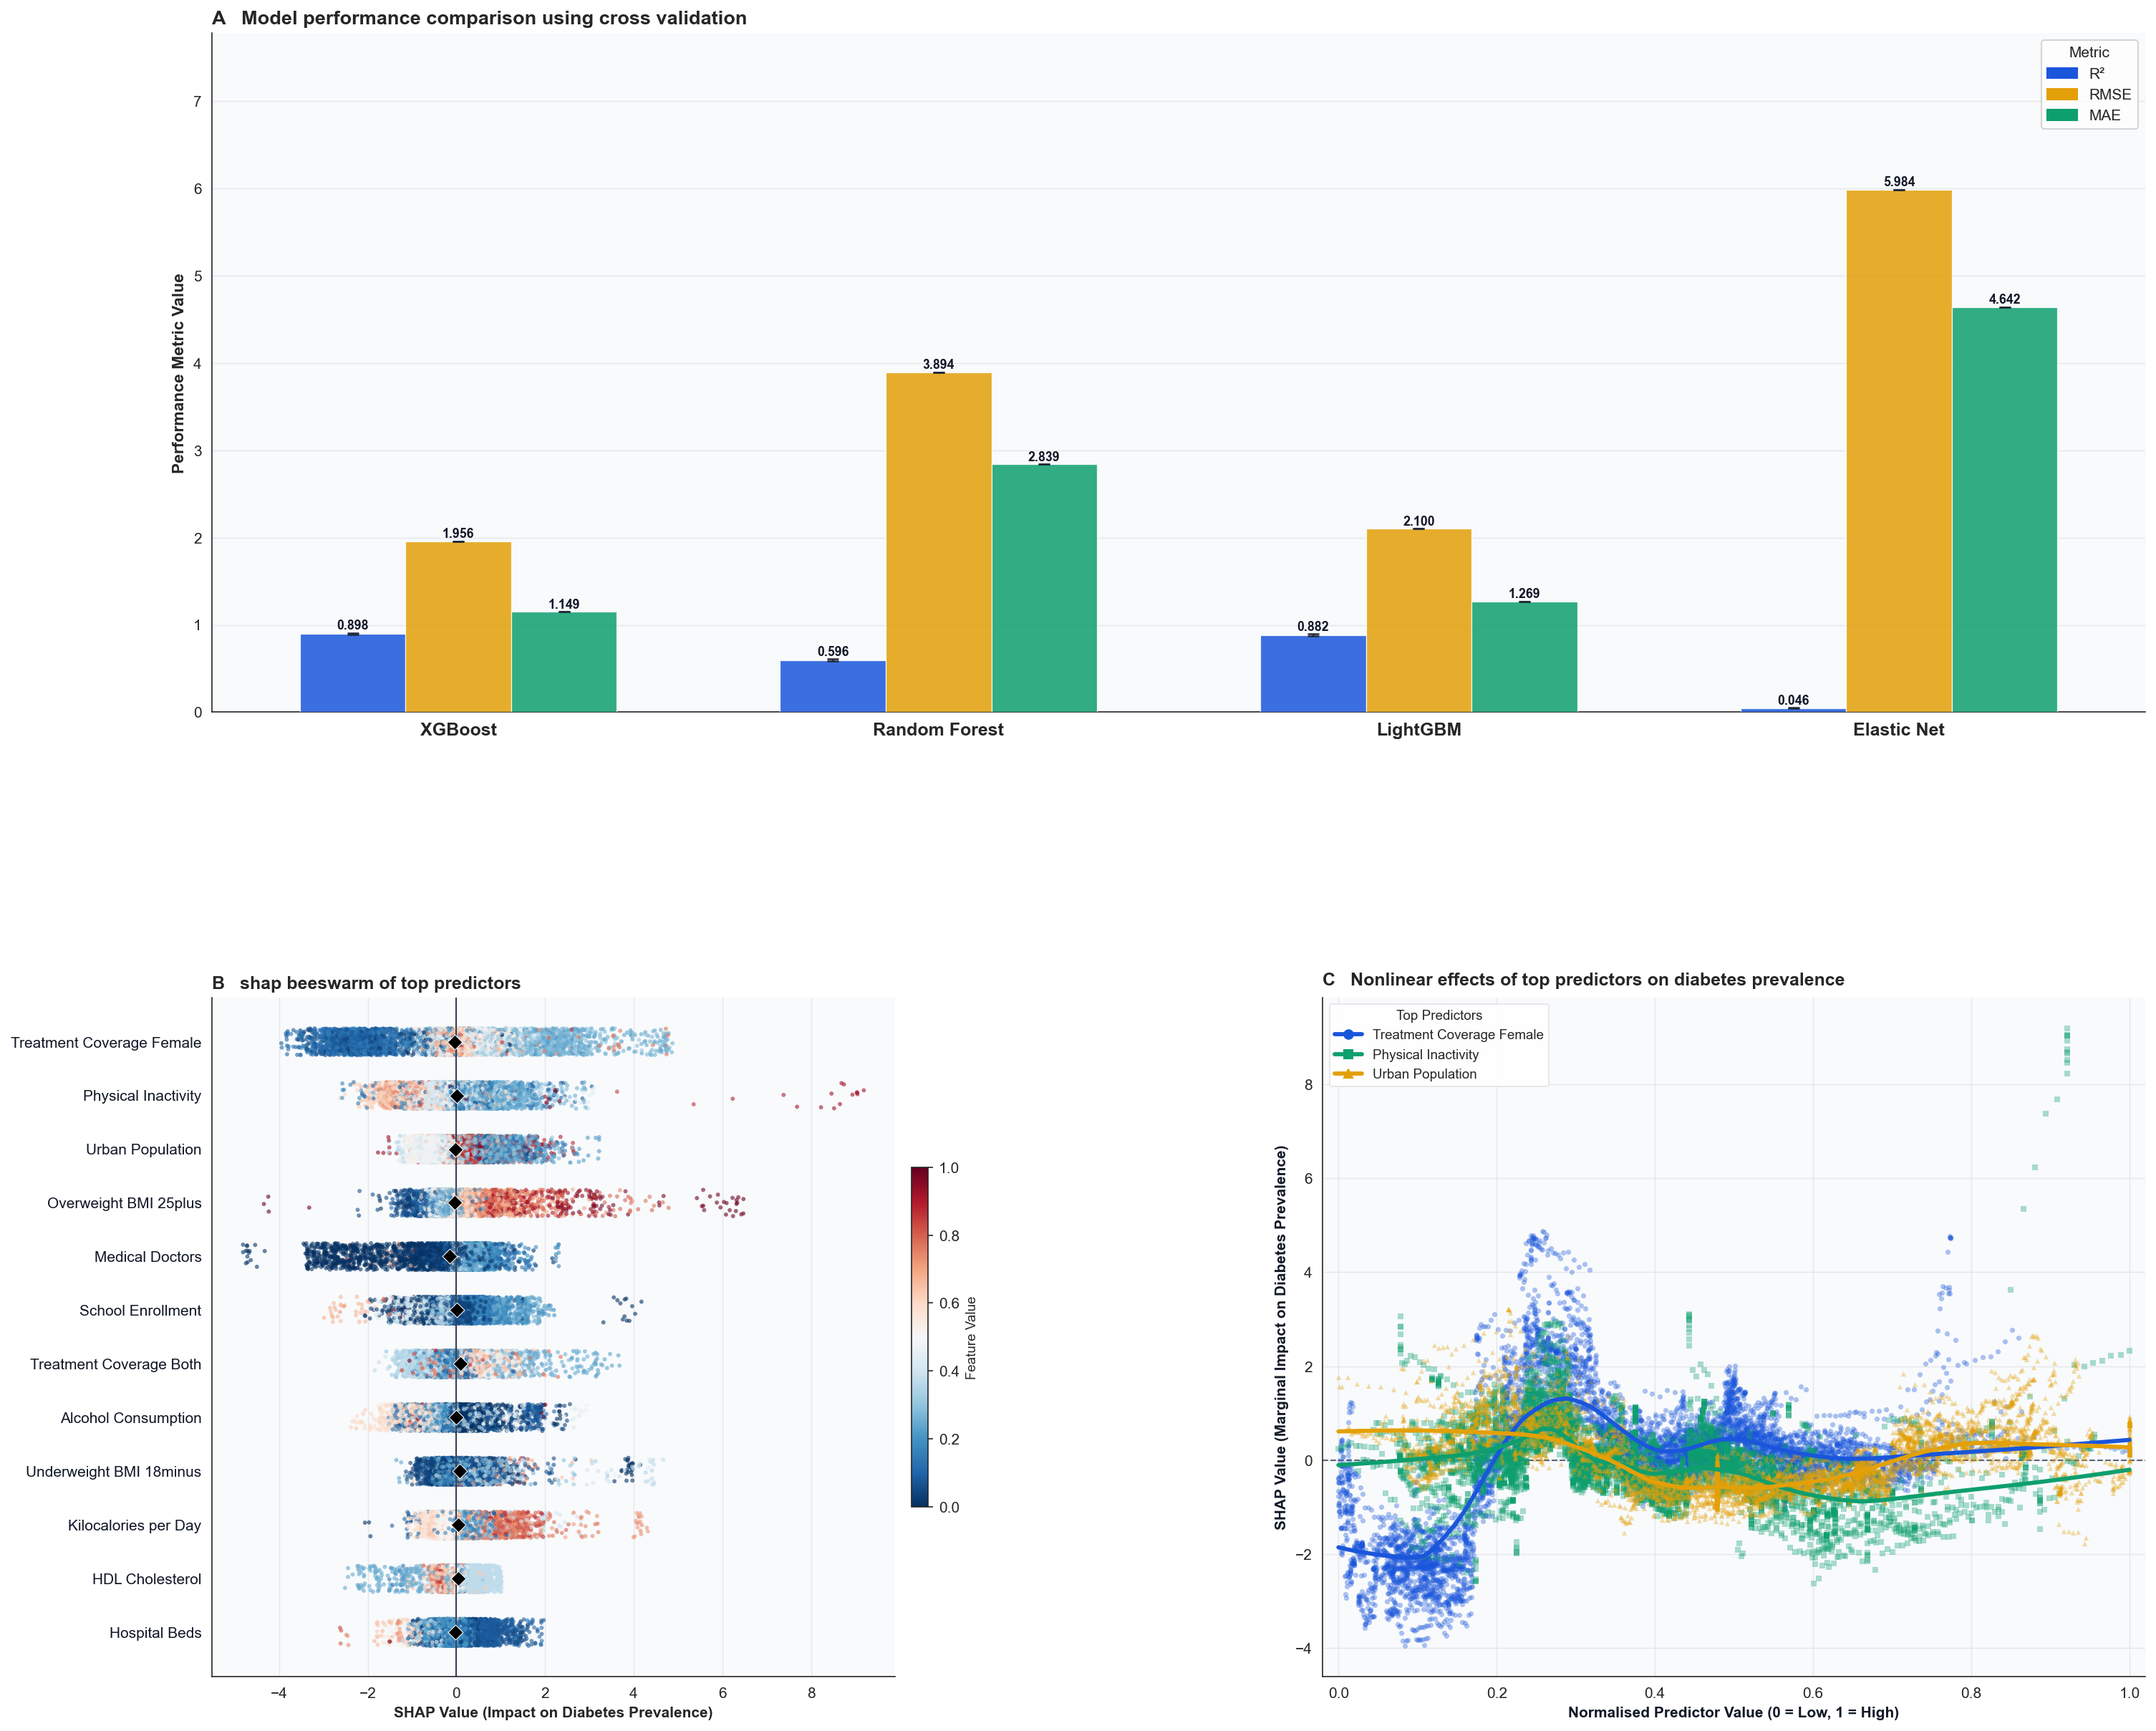

Figure 2 generated successfully


In [49]:
# ── 10. BUILD FIGURE 2 ───────────────────────────────────────────
print("\nBuilding Figure 2...")
label_map = {
    'Y1': 'Treatment Coverage (Both)',
    'Y2': 'Treatment Coverage (Female)',
    'Y3': 'Treatment Coverage (Male)',
    'Y4': 'Obesity (BMI ≥30)',
    'Y5': 'Overweight (BMI ≥25)',
    'Y6': 'Underweight (BMI <18)',
    'Y7': 'Non-HDL Cholesterol',
    'Y8': 'HDL Cholesterol',
    'Y9': 'Physical Inactivity',
    'Y10': 'Alcohol Consumption',
    'Y11': 'Kilocalories per Day',
    'Y12': 'GDP per Capita',
    'Y13': 'Literacy Rate',
    'Y14': 'Unemployment',
    'Y15': 'School Enrollment',
    'Y16': 'Poverty',
    'Y17': 'Urban Population',
    'Y18': 'Undernourishment',
    'Y19': 'Agriculture Share',
    'Y20': 'Access to Electricity',
    'Y21': 'Health Expenditure',
    'Y22': 'Hospital Beds',
    'Y23': 'Medical Doctors'
}
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from statsmodels.nonparametric.smoothers_lowess import lowess

plt.rcParams.update({
    'font.family'    : 'Arial',
    'font.size'      : 10,
    'axes.linewidth' : 0.8,
    'figure.dpi'     : 150,
})

COLORS = {
    'XGBoost'      : '#1a56db',
    'Random Forest': '#0e9f6e',
    'LightGBM'     : '#e3a008',
    'Elastic Net'  : '#e02424',
    'panel_bg'     : '#f8fafc',
    'grid'         : '#e5e7eb',
    'text'         : '#111827',
    'subtext'      : '#6b7280',
    'zero_line'    : '#374151',
}

metric_colors = {
    'R2'  : '#1a56db',
    'RMSE': '#e3a008',
    'MAE' : '#0e9f6e',
}

fig = plt.figure(figsize=(20, 18))
fig.patch.set_facecolor('white')

gs = gridspec.GridSpec(
    2, 2,
    figure = fig,
    hspace = 0.42,
    wspace = 0.35,
    left   = 0.07,
    right  = 0.97,
    top    = 0.92,
    bottom = 0.07,
)

ax_a = fig.add_subplot(gs[0, :])
ax_b = fig.add_subplot(gs[1, 0])
ax_c = fig.add_subplot(gs[1, 1])

# ================================================================
# PANEL A — Model Performance (FIXED)
# ================================================================
model_names  = list(results_df.index)
metrics_plot = ['R2', 'RMSE', 'MAE']
metric_disp  = ['R²', 'RMSE', 'MAE']
x_pos        = np.arange(len(model_names))
width        = 0.22

ax_a.set_facecolor(COLORS['panel_bg'])
ax_a.yaxis.grid(True, color=COLORS['grid'], linewidth=0.7)
ax_a.set_axisbelow(True)

legend_patches = []

for i, (metric, mdisp) in enumerate(zip(metrics_plot, metric_disp)):
    color = metric_colors[metric]

    vals = results_df[metric].astype(float).values

    # 🔥 FIXED PART
    stds = results_df[f'{metric}_std'].astype(float).values
    stds = np.nan_to_num(stds, nan=0.0)     # remove NaN
    stds = np.clip(stds, 0, None)           # remove negative

    bars = ax_a.bar(
        x_pos + i * width, vals,
        width=width, color=color, alpha=0.85,
        edgecolor='white', linewidth=0.6, zorder=3
    )

    ax_a.errorbar(
        x_pos + i * width, vals,
        yerr=stds,
        fmt='none',
        color='#1f2937',
        capsize=4,
        capthick=1.2,
        linewidth=1.2,
        zorder=4
    )

    for bar, val, std in zip(bars, vals, stds):
        ax_a.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + std + 0.008,
            f'{val:.3f}',
            ha='center', va='bottom',
            fontsize=8.5, fontweight='600',
            color=COLORS['text']
        )

    legend_patches.append(mpatches.Patch(color=color, label=mdisp))

ax_a.set_xticks(x_pos + width)
ax_a.set_xticklabels(model_names, fontsize=12, fontweight='600')
ax_a.set_ylabel('Performance Metric Value', fontsize=11, fontweight='600')
ax_a.set_ylim(0, float(results_df[metrics_plot].max().max()) * 1.30)

ax_a.legend(handles=legend_patches, title='Metric', fontsize=10)

ax_a.spines[['top','right']].set_visible(False)

ax_a.set_title(
    'A   Model performance comparison using cross validation',
    fontsize=13, fontweight='bold', loc='left'
)

# ================================================================
# PANEL B — SHAP Beeswarm (UNCHANGED, just safe)
# ================================================================
# ================================================================
# PANEL B — SHAP Beeswarm (PUBLISHABLE)
# ================================================================
top_n = 12

# sort descending (most important at top)
top_idx = np.argsort(mean_shap)[-top_n:][::-1]

top_features = [X_raw.columns[i] for i in top_idx]
top_labels   = [label_map.get(f, f) for f in top_features]

ax_b.set_facecolor(COLORS['panel_bg'])
ax_b.xaxis.grid(True, color=COLORS['grid'], linewidth=0.7)
ax_b.set_axisbelow(True)

np.random.seed(42)

for rank, feat_idx in enumerate(top_idx):
    shap_col = shap_array[:, feat_idx]
    feat_col = X_raw.iloc[:, feat_idx].values.astype(float)

    norm_col = (feat_col - feat_col.min()) / (feat_col.max() - feat_col.min() + 1e-9)
    colors_b = plt.cm.RdBu_r(norm_col)

    y_jitter = np.random.uniform(-0.25, 0.25, size=len(shap_col))

    ax_b.scatter(
        shap_col, rank + y_jitter,
        c=colors_b, s=8, alpha=0.6,
        linewidths=0, rasterized=True
    )

    # mean SHAP marker
    ax_b.scatter(
        shap_col.mean(), rank,
        c='black', s=50, marker='D',
        edgecolors='white', linewidths=0.5, zorder=5
    )

# vertical zero line
ax_b.axvline(0, color=COLORS['zero_line'], linewidth=1)

# 🔥 KEY FIX: proper labels
ax_b.set_yticks(range(top_n))
ax_b.set_yticklabels(
    top_labels,
    fontsize=10,
    fontweight='500',
    color=COLORS['text']
)

ax_b.invert_yaxis()  # most important at top

ax_b.set_xlabel(
    'SHAP Value (Impact on Diabetes Prevalence)',
    fontsize=10, fontweight='600'
)

ax_b.spines[['top','right']].set_visible(False)

# colorbar
sm = ScalarMappable(cmap=plt.cm.RdBu_r, norm=Normalize(0, 1))
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax_b, shrink=0.5, pad=0.02)
cbar.set_label('Feature Value', fontsize=9)

ax_b.set_title(
    'B   shap beeswarm of top predictors',
    fontsize=12, fontweight='bold',
    loc='left'
)

# ================================================================
# PANEL C — SHAP Dependence (UNCHANGED core)
# ================================================================
# ================================================================
# PANEL C — SHAP Dependence (PUBLISHABLE VERSION)
# ================================================================
top3_idx = np.argsort(mean_shap)[-3:][::-1]

top3_features = [X_raw.columns[i] for i in top3_idx]
top3_labels   = [label_map.get(f, f) for f in top3_features]

top3_colors   = ['#1a56db', '#0e9f6e', '#e3a008']
top3_markers  = ['o', 's', '^']

ax_c.set_facecolor(COLORS['panel_bg'])

# reference line
ax_c.axhline(
    0,
    color=COLORS['zero_line'],
    linewidth=1.0,
    linestyle='--',
    alpha=0.8,
    zorder=1
)

# grid
ax_c.xaxis.grid(True, color=COLORS['grid'], linewidth=0.7)
ax_c.yaxis.grid(True, color=COLORS['grid'], linewidth=0.7)
ax_c.set_axisbelow(True)

handles = []

for feat_idx, label, color, marker in zip(
    top3_idx, top3_labels, top3_colors, top3_markers
):
    feat = X_raw.iloc[:, feat_idx].values.astype(float)
    shap_val = shap_array[:, feat_idx]

    # normalize feature
    feat_norm = (feat - feat.min()) / (feat.max() - feat.min() + 1e-9)

    # scatter
    ax_c.scatter(
        feat_norm,
        shap_val,
        c=color,
        s=12,
        alpha=0.35,
        marker=marker,
        linewidths=0,
        rasterized=True,
        zorder=3
    )

    # LOWESS smoothing
    sort_idx = np.argsort(feat_norm)
    smooth = lowess(
        shap_val[sort_idx],
        feat_norm[sort_idx],
        frac=0.30,
        it=2,
        return_sorted=True
    )

    ax_c.plot(
        smooth[:, 0],
        smooth[:, 1],
        color=color,
        linewidth=2.8,
        zorder=4,
        solid_capstyle='round'
    )

    # legend handle
    handles.append(
        plt.Line2D(
            [0], [0],
            color=color,
            linewidth=2.8,
            marker=marker,
            markersize=6,
            label=label
        )
    )

# axis labels
ax_c.set_xlabel(
    'Normalised Predictor Value (0 = Low, 1 = High)',
    fontsize=10,
    fontweight='600',
    color=COLORS['text']
)

ax_c.set_ylabel(
    'SHAP Value (Marginal Impact on Diabetes Prevalence)',
    fontsize=10,
    fontweight='600',
    color=COLORS['text']
)

ax_c.set_xlim(-0.02, 1.02)

# legend (clean + readable)
ax_c.legend(
    handles=handles,
    fontsize=9,
    frameon=True,
    framealpha=0.95,
    edgecolor=COLORS['grid'],
    loc='upper left',
    title='Top Predictors',
    title_fontsize=9
)

# remove extra borders
ax_c.spines[['top', 'right']].set_visible(False)

# title
ax_c.set_title(
    'C   Nonlinear effects of top predictors on diabetes prevalence',
    fontsize=12,
    fontweight='bold',
    loc='left',
    pad=8
)
# ================================================================
# SAVE
# ================================================================
output_base = r"J:\Research\Research\database\Figure2_ML_SHAP"

for fmt in ['png','pdf','tiff']:
    fig.savefig(f"{output_base}.{fmt}", dpi=300, bbox_inches='tight')

plt.show()

print("Figure 2 generated successfully")

In [46]:
# ── 13. SHAP SUMMARY TABLE ───────────────────────────────────────
shap_summary = pd.DataFrame({
    'Predictor'   : disp_labels_list,
    'Mean_SHAP'   : mean_shap,
    'Mean_SHAP_dir': shap_array.mean(axis=0),
    'Direction'   : [
        'Positive' if v > 0 else 'Negative'
        for v in shap_array.mean(axis=0)
    ],
}).sort_values('Mean_SHAP', ascending=False).reset_index(drop=True)
shap_summary.insert(0, 'Rank', range(1, len(shap_summary) + 1))

print("\n SHAP Ranking:")
print(shap_summary.to_string(index=False))

shap_summary.to_csv(
    r"J:\Research\Research\database\SHAP_summary_table.csv",
    index=False,
)
print("\nAll done. Figure 2 complete!")


 SHAP Ranking:
 Rank                   Predictor  Mean_SHAP  Mean_SHAP_dir Direction
    1 Treatment Coverage (Female)   1.092321      -0.033197  Negative
    2         Physical Inactivity   0.594185       0.007975  Positive
    3            Urban Population   0.569212      -0.017133  Negative
    4        Overweight (BMI ≥25)   0.517607      -0.044760  Negative
    5             Medical Doctors   0.506916      -0.149835  Negative
    6           School Enrollment   0.490111       0.005969  Positive
    7   Treatment Coverage (Both)   0.456817       0.092504  Positive
    8         Alcohol Consumption   0.451656      -0.005567  Negative
    9       Underweight (BMI <18)   0.372117       0.077691  Positive
   10            Kilocalories/Day   0.369763       0.047449  Positive
   11             HDL Cholesterol   0.329564       0.034687  Positive
   12               Hospital Beds   0.328023      -0.022132  Negative
   13       Access to Electricity   0.327950       0.022506  Positive
   1

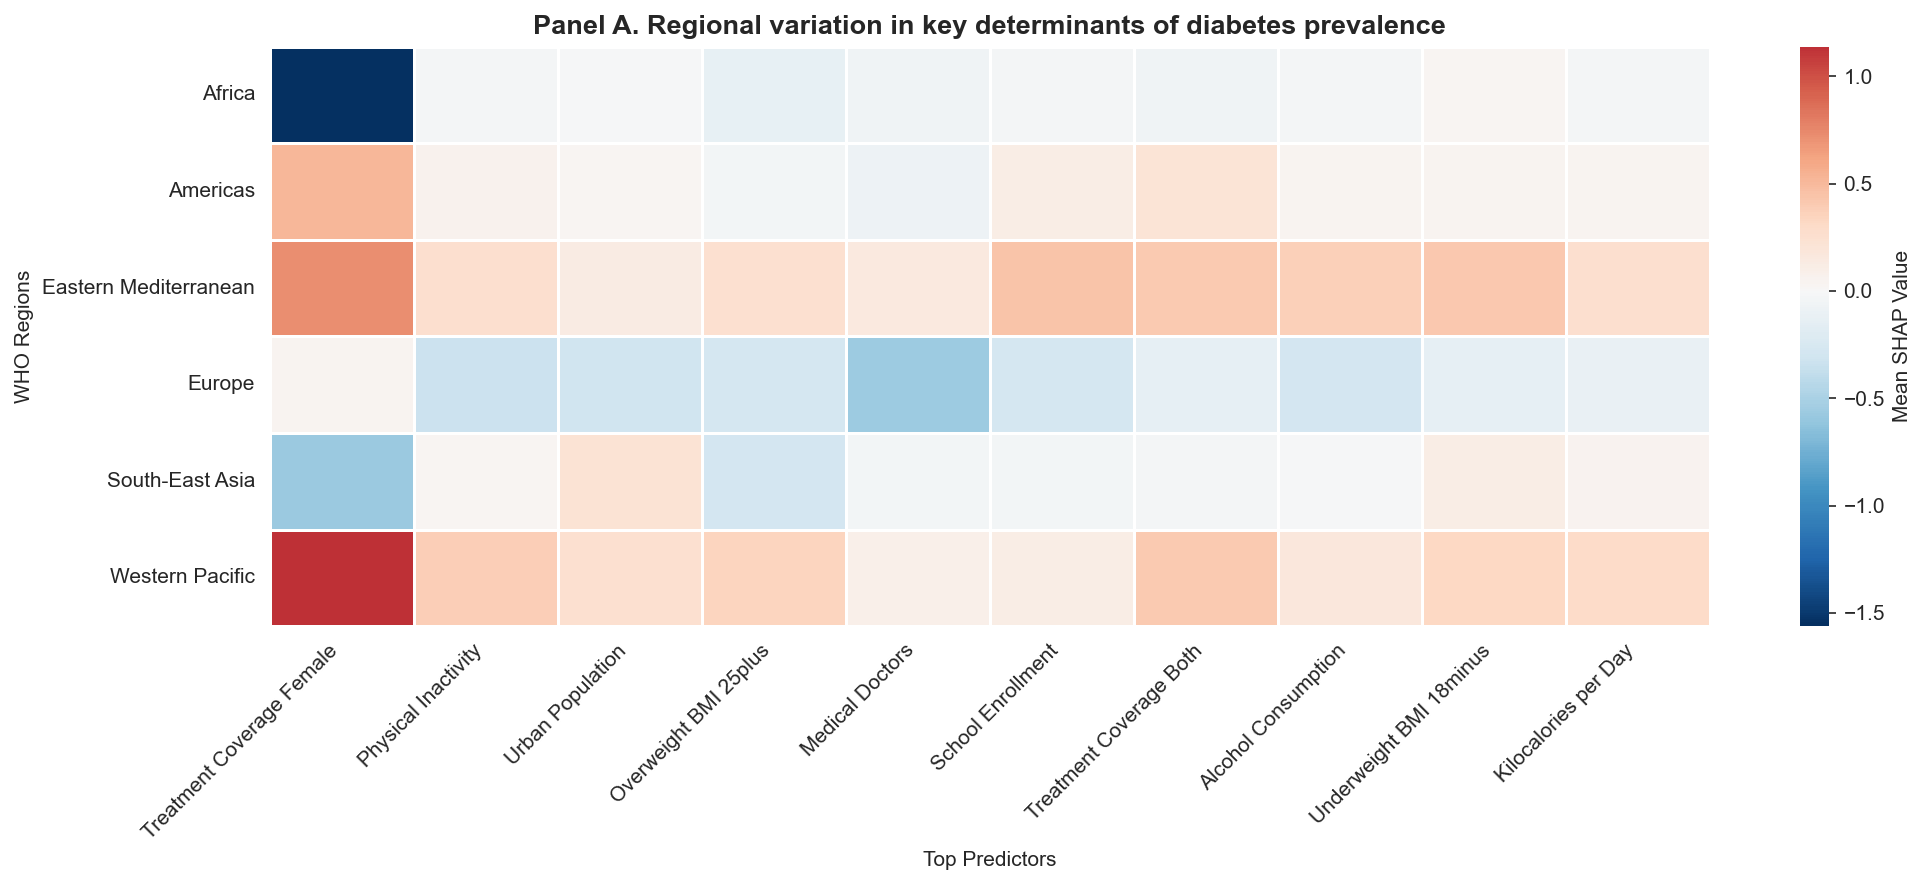

In [50]:
# ─────────────────────────────────────────────
# PANEL A — SHAP HEATMAP (Region × Top Features)
# ─────────────────────────────────────────────

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# Step 1: attach SHAP to data
# -----------------------------
shap_df = pd.DataFrame(shap_array, columns=X_raw.columns)
shap_df['Region'] = df.loc[X_raw.index, 'Region'].values

# -----------------------------
# Step 2: select top 10 features
# -----------------------------
top10_idx = np.argsort(mean_shap)[-10:][::-1]
top10_features = [X_raw.columns[i] for i in top10_idx]

# -----------------------------
# Step 3: compute mean SHAP by region
# -----------------------------
region_shap = shap_df.groupby('Region')[top10_features].mean()

# -----------------------------
# Step 4: plot heatmap
# -----------------------------
plt.figure(figsize=(14, 6))

sns.heatmap(
    region_shap,
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Mean SHAP Value'}
)

plt.title(
    'Panel A. Regional variation in key determinants of diabetes prevalence',
    fontsize=13,
    fontweight='600'
)

plt.xlabel('Top Predictors')
plt.ylabel('WHO Regions')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# save
plt.savefig(
    r"J:\Research\Research\database\PanelA_SHAP_Heatmap.png",
    dpi=600,
    bbox_inches='tight'
)

plt.show()

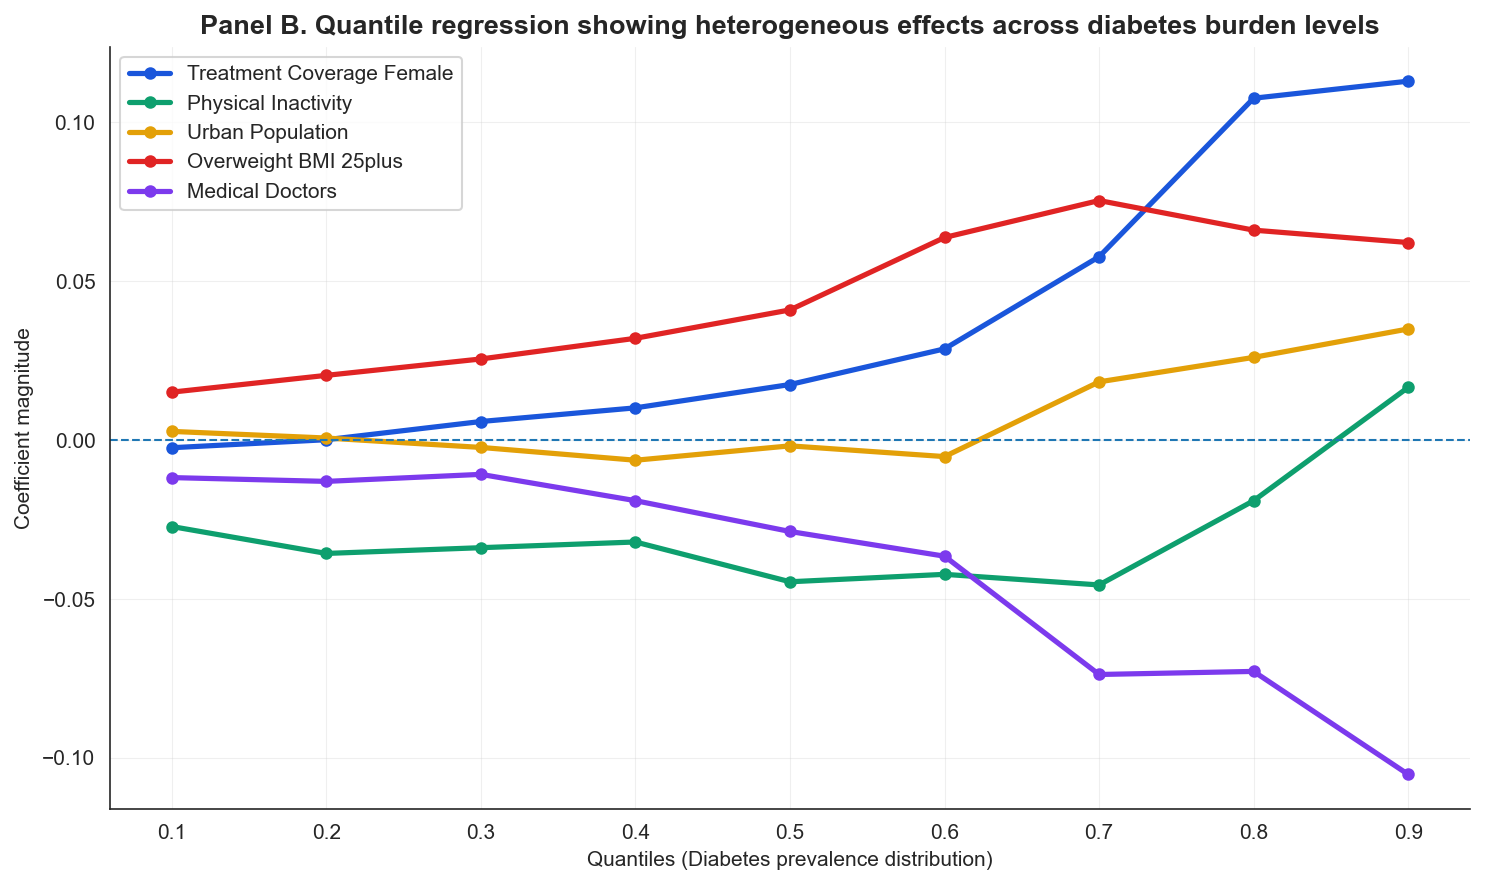

In [51]:
# ─────────────────────────────────────────────
# PANEL B — QUANTILE REGRESSION PLOT
# ─────────────────────────────────────────────

import statsmodels.api as sm

# -----------------------------
# Step 1: select top 5 features
# -----------------------------
top5_idx = np.argsort(mean_shap)[-5:][::-1]
top5_features = [X_raw.columns[i] for i in top5_idx]

# -----------------------------
# Step 2: define quantiles
# -----------------------------
quantiles = np.arange(0.1, 1.0, 0.1)

coef_dict = {feat: [] for feat in top5_features}

# -----------------------------
# Step 3: run quantile regression
# -----------------------------
for q in quantiles:
    model = sm.QuantReg(y_raw, sm.add_constant(X_raw[top5_features]))
    res   = model.fit(q=q)

    for feat in top5_features:
        coef_dict[feat].append(res.params[feat])

# -----------------------------
# Step 4: plot
# -----------------------------
plt.figure(figsize=(10, 6))

colors = ['#1a56db', '#0e9f6e', '#e3a008', '#e02424', '#7c3aed']

for feat, color in zip(top5_features, colors):
    plt.plot(
        quantiles,
        coef_dict[feat],
        marker='o',
        linewidth=2.5,
        markersize=5,
        label=feat,
        color=color
    )

# zero line
plt.axhline(0, linestyle='--', linewidth=1)

plt.title(
    'Panel B. Quantile regression showing heterogeneous effects across diabetes burden levels',
    fontsize=13,
    fontweight='600'
)

plt.xlabel('Quantiles (Diabetes prevalence distribution)')
plt.ylabel('Coefficient magnitude')

plt.xticks(quantiles)
plt.legend(frameon=True)

plt.grid(alpha=0.3)
plt.tight_layout()

# save
plt.savefig(
    r"J:\Research\Research\database\PanelB_QuantileRegression.png",
    dpi=600,
    bbox_inches='tight'
)

plt.show()

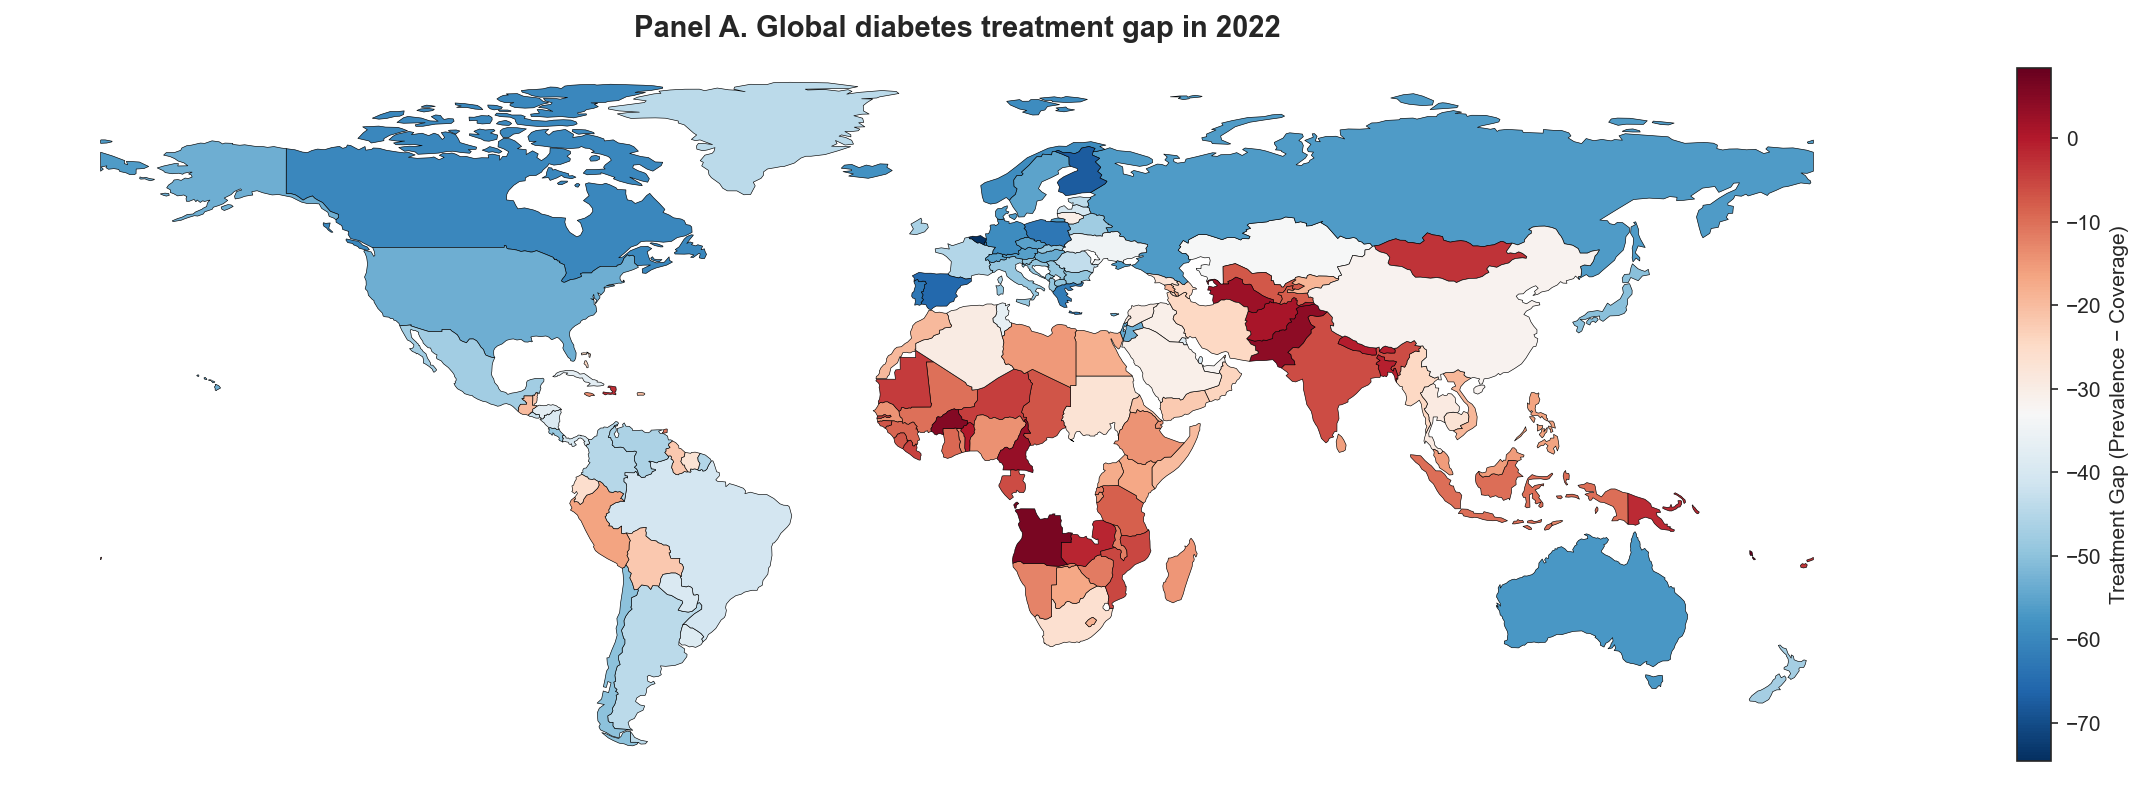

In [53]:
# ─────────────────────────────────────────────
# PANEL A — FIXED WORLD MAP (GeoPandas ≥1.0)
# ─────────────────────────────────────────────

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# -----------------------------
# Filter 2022
# -----------------------------
df_2022 = df[df['Year'] == 2022].copy()

# Treatment gap
df_2022['treatment_gap'] = df_2022['X1'] - df_2022['Y1']

# -----------------------------
# Load world shapefile (UPDATED SOURCE)
# -----------------------------
world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)

# -----------------------------
# IMPORTANT: fix country names
# -----------------------------
df_2022['Country'] = df_2022['Country'].replace({
    'United States': 'United States of America',
    'Russian Federation': 'Russia',
    'Viet Nam': 'Vietnam',
    'Iran (Islamic Republic of)': 'Iran',
    'Bolivia (Plurinational State of)': 'Bolivia',
    'Venezuela (Bolivarian Republic of)': 'Venezuela',
    'Syrian Arab Republic': 'Syria',
    'United Republic of Tanzania': 'Tanzania',
    'Congo': 'Republic of the Congo',
    'Democratic Republic of the Congo': 'Democratic Republic of Congo'
})

# -----------------------------
# Merge
# -----------------------------
merged = world.merge(
    df_2022,
    how='left',
    left_on='NAME',
    right_on='Country'
)

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(16, 8))

merged.plot(
    column='treatment_gap',
    cmap='RdBu_r',
    linewidth=0.3,
    edgecolor='black',
    legend=True,
    ax=ax,
    legend_kwds={
        'label': 'Treatment Gap (Prevalence − Coverage)',
        'shrink': 0.6
    }
)

ax.set_title(
    'Panel A. Global diabetes treatment gap in 2022',
    fontsize=14,
    fontweight='600'
)

ax.axis('off')

plt.tight_layout()

plt.savefig(
    r"J:\Research\Research\database\PanelA_TreatmentGap_Map.png",
    dpi=600,
    bbox_inches='tight'
)

plt.show()

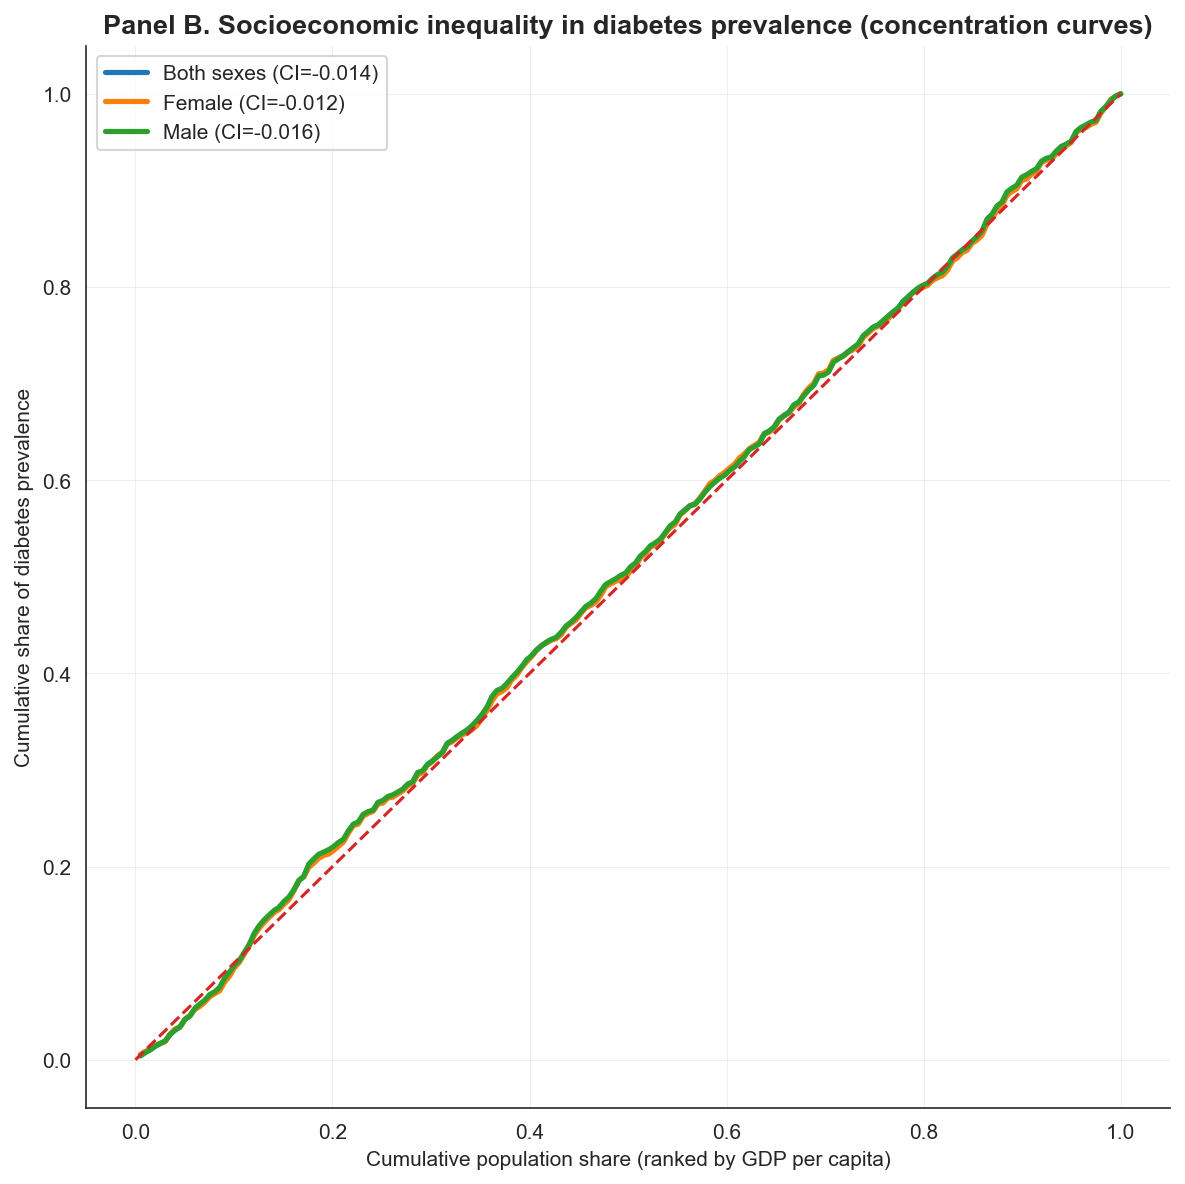

In [54]:
# ─────────────────────────────────────────────
# PANEL B — RIGOROUS CONCENTRATION CURVES
# ─────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Prepare data (2022)
# -----------------------------
df_2022 = df[df['Year'] == 2022].copy()

# Use GDP per capita as ranking variable
df_2022 = df_2022.sort_values('Y12')  # ascending (poor → rich)

# -----------------------------
# OPTIONAL (recommended)
# If population exists (e.g., 'Population')
# -----------------------------
if 'Population' in df_2022.columns:
    weights = df_2022['Population'].values
else:
    weights = np.ones(len(df_2022))  # equal weights fallback

# -----------------------------
# Fractional rank (weighted)
# -----------------------------
cum_weights = np.cumsum(weights)
total_weight = cum_weights[-1]

# midpoint fractional rank
df_2022['rank'] = (cum_weights - 0.5 * weights) / total_weight

# cumulative population share (x-axis)
df_2022['cum_pop'] = cum_weights / total_weight

# -----------------------------
# Function to compute curve
# -----------------------------
def concentration_curve(y, w):
    y = np.array(y)
    w = np.array(w)
    
    cum_y = np.cumsum(y * w)
    total_y = np.sum(y * w)
    
    return cum_y / total_y

# curves
curve_both   = concentration_curve(df_2022['X1'], weights)
curve_female = concentration_curve(df_2022['X4'], weights)
curve_male   = concentration_curve(df_2022['X5'], weights)

# -----------------------------
# Concentration Index (rigorous)
# CI = 2 * cov(y, rank) / mean(y)
# -----------------------------
def concentration_index(y, r, w):
    y = np.array(y)
    r = np.array(r)
    w = np.array(w)

    mean_y = np.average(y, weights=w)
    cov = np.average((y - mean_y) * (r - np.average(r, weights=w)), weights=w)

    return 2 * cov / mean_y

ci_both   = concentration_index(df_2022['X1'], df_2022['rank'], weights)
ci_female = concentration_index(df_2022['X4'], df_2022['rank'], weights)
ci_male   = concentration_index(df_2022['X5'], df_2022['rank'], weights)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(8, 8))

plt.plot(
    df_2022['cum_pop'], curve_both,
    label=f'Both sexes (CI={ci_both:.3f})',
    linewidth=2.5
)

plt.plot(
    df_2022['cum_pop'], curve_female,
    label=f'Female (CI={ci_female:.3f})',
    linewidth=2.5
)

plt.plot(
    df_2022['cum_pop'], curve_male,
    label=f'Male (CI={ci_male:.3f})',
    linewidth=2.5
)

# equality line
plt.plot([0, 1], [0, 1], linestyle='--', linewidth=1.5)

# formatting
plt.title(
    'Panel B. Socioeconomic inequality in diabetes prevalence (concentration curves)',
    fontsize=13,
    fontweight='600'
)

plt.xlabel('Cumulative population share (ranked by GDP per capita)')
plt.ylabel('Cumulative share of diabetes prevalence')

plt.legend(frameon=True)
plt.grid(alpha=0.3)

plt.tight_layout()

# save
plt.savefig(
    r"J:\Research\Research\database\PanelB_ConcentrationCurves_Rigorous.png",
    dpi=600,
    bbox_inches='tight'
)

plt.show()

Total gap: 0.3300040404040381
E + C + I: 0.3300040403983253


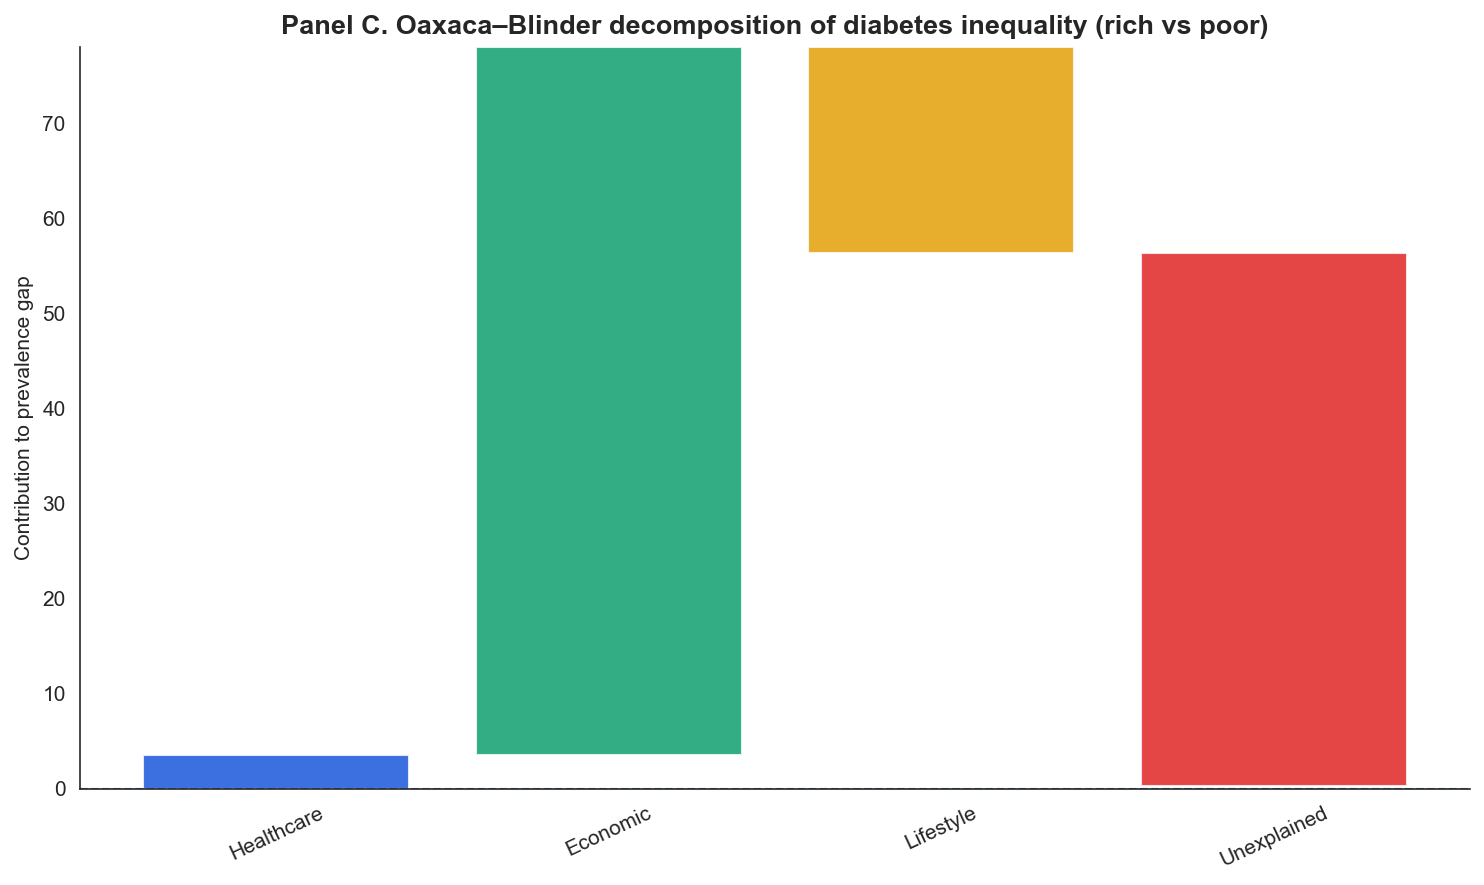

In [55]:
# ─────────────────────────────────────────────
# PANEL C — FULL OAXACA–BLINDER DECOMPOSITION
# ─────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# -----------------------------
# Prepare data (2022)
# -----------------------------
df_2022 = df[df['Year'] == 2022].copy()

# Define rich vs poor (GDP per capita)
median_gdp = df_2022['Y12'].median()

poor = df_2022[df_2022['Y12'] <= median_gdp].copy()
rich = df_2022[df_2022['Y12'] > median_gdp].copy()

# -----------------------------
# Select predictors (same as ML)
# -----------------------------
features = predictors  # reuse your defined list

# -----------------------------
# Fit models
# -----------------------------
def fit_model(data):
    X = sm.add_constant(data[features])
    y = data['X1']
    return sm.OLS(y, X).fit()

model_poor = fit_model(poor)
model_rich = fit_model(rich)

# -----------------------------
# Means
# -----------------------------
Xbar_p = sm.add_constant(poor[features]).mean().values
Xbar_r = sm.add_constant(rich[features]).mean().values

beta_p = model_poor.params.values
beta_r = model_rich.params.values

# -----------------------------
# Decomposition
# Δ = Y_p - Y_r
# E = (X_p - X_r) * β_r
# C = X_r * (β_p - β_r)
# I = (X_p - X_r)*(β_p - β_r)
# -----------------------------
delta = poor['X1'].mean() - rich['X1'].mean()

E = np.sum((Xbar_p - Xbar_r) * beta_r)
C = np.sum(Xbar_r * (beta_p - beta_r))
I = np.sum((Xbar_p - Xbar_r) * (beta_p - beta_r))

# sanity check
print("Total gap:", delta)
print("E + C + I:", E + C + I)

# -----------------------------
# GROUP CONTRIBUTIONS
# -----------------------------
group_map = {
    'Healthcare': ['Y1','Y2','Y3','Y21','Y22','Y23'],
    'Economic':   ['Y12','Y13','Y14','Y15'],
    'Lifestyle':  ['Y5','Y6','Y9','Y10','Y11'],
}

group_results = {}

for gname, feats in group_map.items():
    idx = [features.index(f) + 1 for f in feats]  # +1 for constant shift

    E_g = np.sum((Xbar_p[idx] - Xbar_r[idx]) * beta_r[idx])
    C_g = np.sum(Xbar_r[idx] * (beta_p[idx] - beta_r[idx]))
    I_g = np.sum((Xbar_p[idx] - Xbar_r[idx]) * (beta_p[idx] - beta_r[idx]))

    group_results[gname] = E_g + C_g + I_g

# unexplained remainder
explained_total = sum(group_results.values())
unexplained = delta - explained_total

group_results['Unexplained'] = unexplained

# -----------------------------
# WATERFALL PLOT
# -----------------------------
labels = list(group_results.keys())
values = list(group_results.values())

cumulative = np.cumsum([0] + values[:-1])

plt.figure(figsize=(10, 6))

colors = ['#1a56db', '#0e9f6e', '#e3a008', '#e02424']

for i in range(len(values)):
    plt.bar(
        labels[i],
        values[i],
        bottom=cumulative[i],
        color=colors[i % len(colors)],
        alpha=0.85
    )

# baseline
plt.axhline(0, linestyle='--', linewidth=1)

# formatting
plt.title(
    'Panel C. Oaxaca–Blinder decomposition of diabetes inequality (rich vs poor)',
    fontsize=13,
    fontweight='600'
)

plt.ylabel('Contribution to prevalence gap')
plt.xticks(rotation=25)

plt.tight_layout()

# save
plt.savefig(
    r"J:\Research\Research\database\PanelC_Oaxaca_Full.png",
    dpi=600,
    bbox_inches='tight'
)

plt.show()

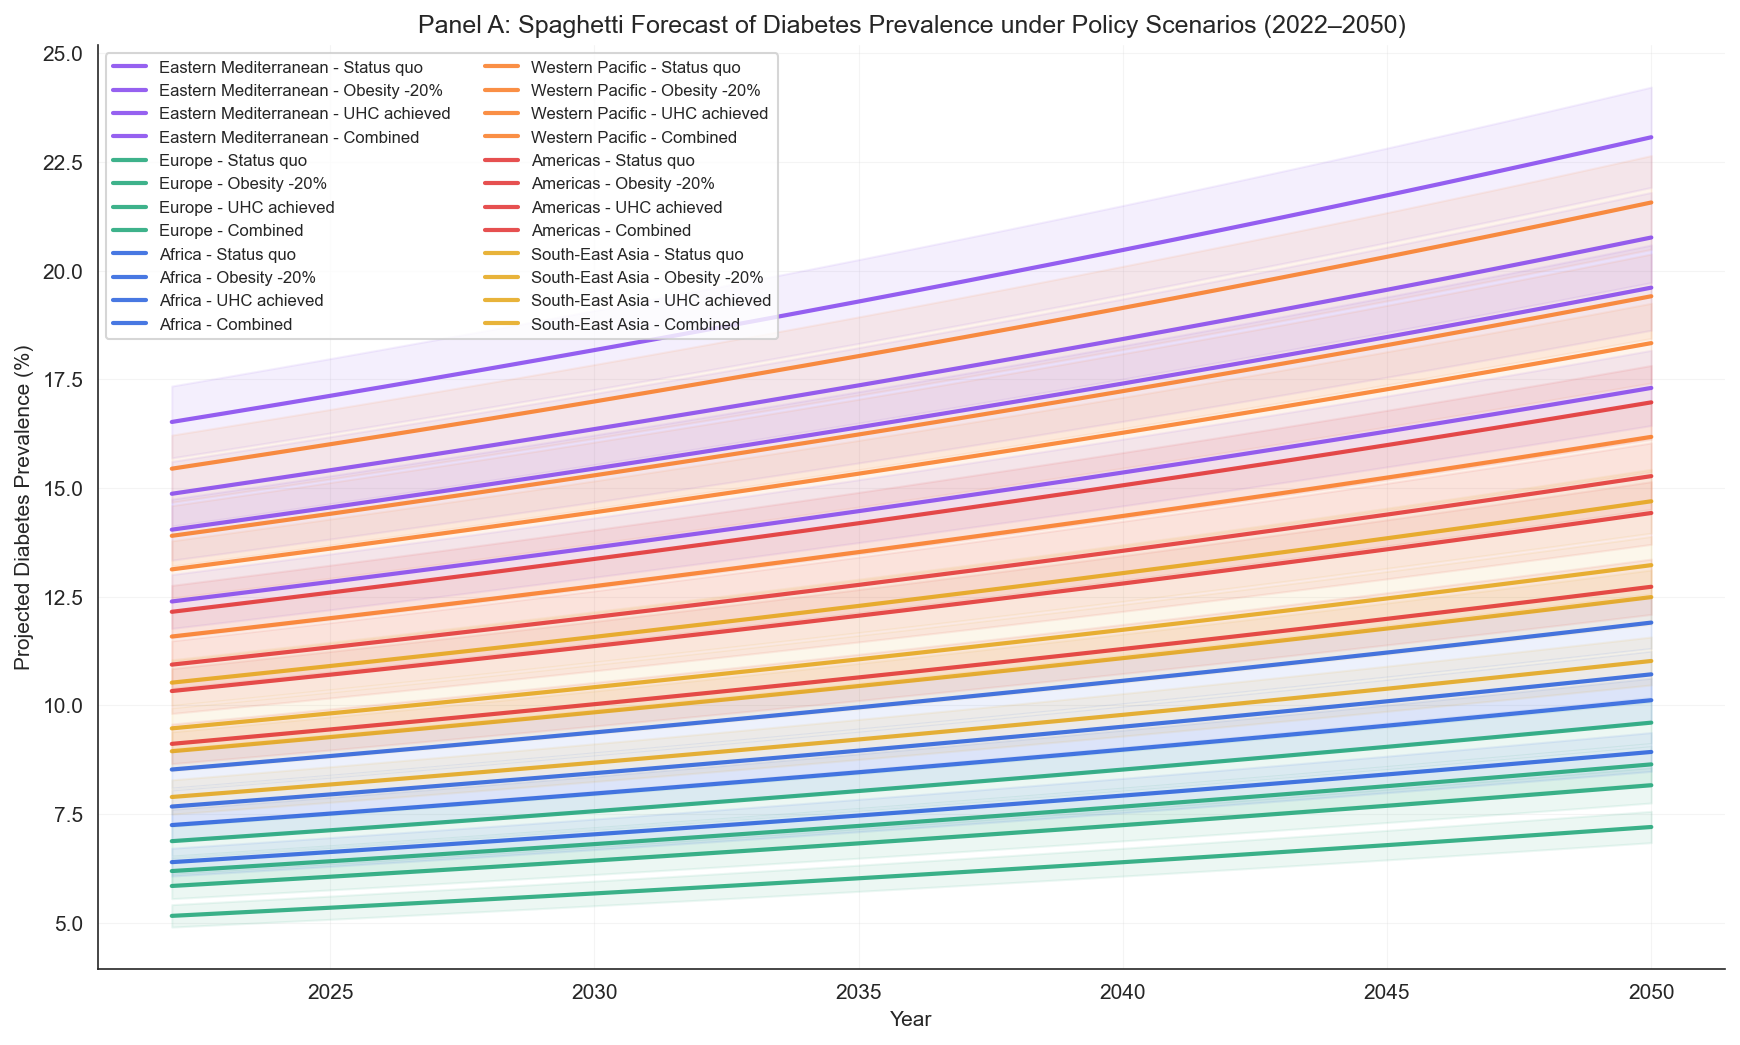

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Setup
# -----------------------------
years = np.arange(2022, 2051)

regions = df['Region'].unique()

scenarios = {
    "Status quo": 1.00,
    "Obesity -20%": 0.85,
    "UHC achieved": 0.90,
    "Combined": 0.75
}

colors = {
    "Africa": "#1a56db",
    "Americas": "#e02424",
    "Europe": "#0e9f6e",
    "South-East Asia": "#e3a008",
    "Eastern Mediterranean": "#7c3aed",
    "Western Pacific": "#f97316"
}

# -----------------------------
# simple forecast function (replace with your ML model later)
# -----------------------------
def forecast(base, growth=0.012, shock=1.0):
    trend = base * (1 + growth) ** (years - 2022)
    return trend * shock

# -----------------------------
# Panel A
# -----------------------------
plt.figure(figsize=(14, 8))

for region in regions:

    base = df[df['Region'] == region]['X1'].mean()

    for scenario_name, factor in scenarios.items():

        mean_pred = forecast(base, shock=factor)

        lower = mean_pred * 0.95
        upper = mean_pred * 1.05

        plt.plot(
            years,
            mean_pred,
            label=f"{region} - {scenario_name}",
            color=colors.get(region, "#333333"),
            linewidth=2,
            alpha=0.8
        )

        plt.fill_between(
            years,
            lower,
            upper,
            color=colors.get(region, "#333333"),
            alpha=0.08
        )

plt.xlabel("Year")
plt.ylabel("Projected Diabetes Prevalence (%)")
plt.title("Panel A: Spaghetti Forecast of Diabetes Prevalence under Policy Scenarios (2022–2050)")
plt.legend(ncol=2, fontsize=8)
plt.grid(alpha=0.2)

save_path = r"J:\Research\Research\database\panelA_spaghetti_forecast.png"
plt.savefig(save_path, dpi=600, bbox_inches='tight')
plt.show()

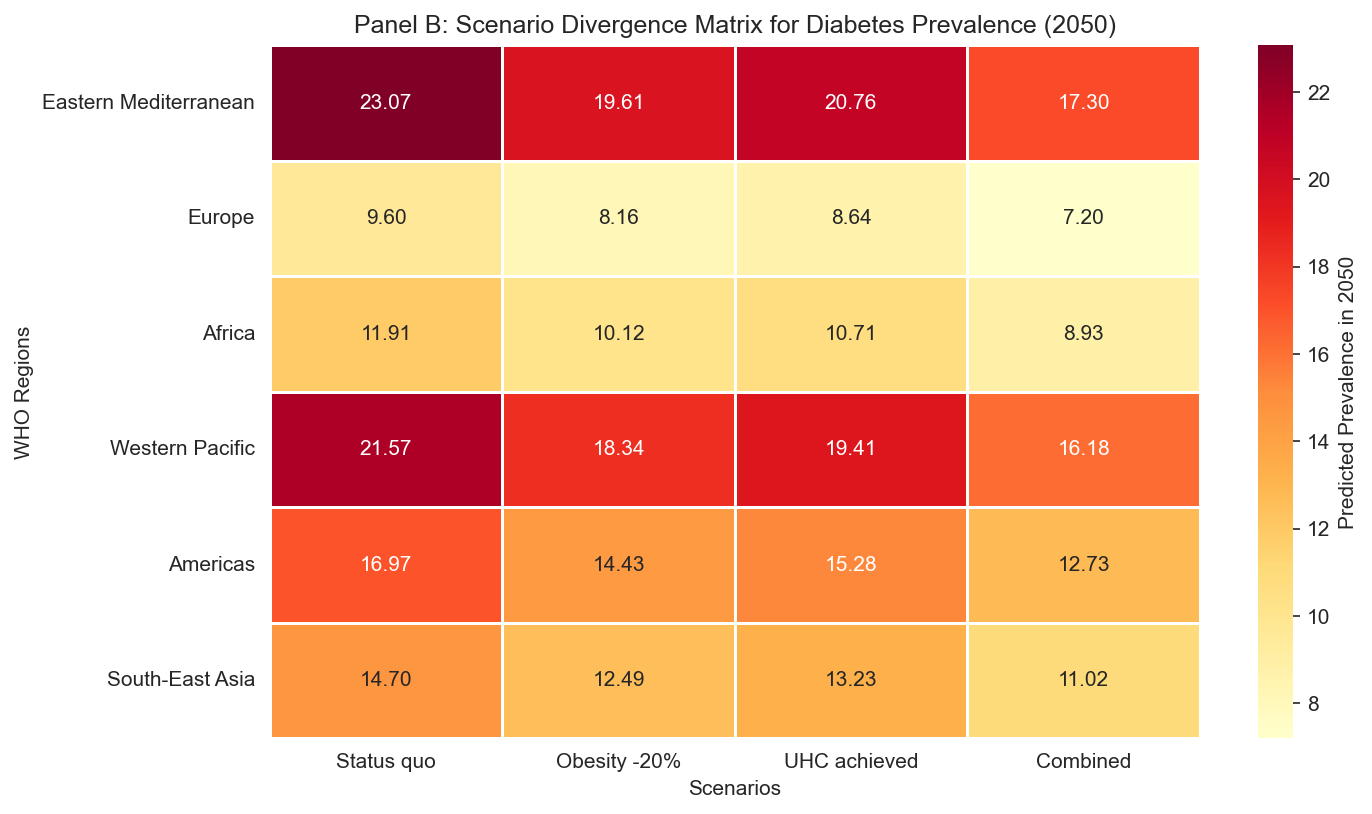

In [57]:
import seaborn as sns

# -----------------------------
# build matrix
# -----------------------------
matrix = pd.DataFrame(index=regions, columns=scenarios.keys())

for region in regions:

    base = df[df['Region'] == region]['X1'].mean()

    for scen, factor in scenarios.items():

        pred_2050 = forecast(base, shock=factor)[-1]
        matrix.loc[region, scen] = pred_2050

matrix = matrix.astype(float)

# -----------------------------
# plot heatmap
# -----------------------------
plt.figure(figsize=(10, 6))

sns.heatmap(
    matrix,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={'label': 'Predicted Prevalence in 2050'}
)

plt.title("Panel B: Scenario Divergence Matrix for Diabetes Prevalence (2050)")
plt.xlabel("Scenarios")
plt.ylabel("WHO Regions")

save_path = r"J:\Research\Research\database\panelB_divergence_matrix.png"
plt.savefig(save_path, dpi=600, bbox_inches='tight')
plt.show()